# Advanced KG-RAG Evaluation: BioMistral-7B

## Mitigating Hallucinations in Medical LLMs via Knowledge-Graph-Augmented Retrieval

This notebook implements and evaluates **four advanced retrieval-augmented generation (RAG) architectures** for rare disease diagnosis using the **BioMistral-7B** language model. Each architecture integrates a biomedical knowledge graph with dense passage retrieval to reduce hallucination rates.

### Architectures Evaluated

| # | Architecture | Reference | Strategy |
|---|-------------|-----------|----------|
| 1 | **GraphRAG** | Edge et al., 2024 | KG community summaries + dense retrieval |
| 2 | **KG-Augmented RAG (KAPING)** | Baek et al., 2023 | Structured KG triples + dense retrieval |
| 3 | **RAG-driven CoT** | Wang et al., 2025 | Retrieve-then-reason with 5-question CoT |
| 4 | **CoT-driven RAG** | Wang et al., 2025 | Decompose-retrieve-synthesize with CoT |

### Hallucination Mitigation Strategies
- **Mod 1** — Forced-commitment format constraint (eliminates passive abstention)
- **Mod 2** — HPO query expansion before FAISS retrieval (improves recall)
- **Mod 3** — Self-consistency voting (n=3, temperature=0.4)
- **Mod 4** — Tightened abstention detection on extracted diagnosis only

### Experimental Setup
| Parameter | Value |
|-----------|-------|
| **Model** | BioMistral/BioMistral-7B (4-bit quantized) |
| **Dataset** | RareBench eval subset (n=120, seed=42) |
| **Embeddings** | PubMedBERT (biomed) + all-MiniLM-L6-v2 (fast) |
| **Knowledge Graph** | 335 nodes, 841 synthetic edges |
| **RAG Corpus** | 130,316 biomedical documents |
| **Evaluation** | Med-HALT taxonomy (Pal et al., EMNLP 2023) |

---
## 1. Environment Setup & Dependencies

Install required packages and configure GPU environment, publication-quality plot defaults, and HuggingFace model cache.

In [1]:
# ── Install dependencies ───────────────────────────────────────────────────────
%pip install -q transformers sentence_transformers datasets accelerate bitsandbytes seaborn matplotlib pandas numpy networkx rouge_score
# faiss-gpu-cu12 for Kaggle GPU; falls back to faiss-cpu on CPU-only machines
%pip install -q faiss-gpu-cu12 2>/dev/null || %pip install -q faiss-cpu

import os
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
import json
import shutil
import hashlib
import unicodedata
import torch
import gc
import re
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from rouge_score import rouge_scorer
from IPython.display import display
import time
from huggingface_hub import snapshot_download
from transformers import (
    pipeline, AutoModelForCausalLM, AutoTokenizer, AutoConfig,
    BitsAndBytesConfig, GenerationConfig,
)
from sentence_transformers import SentenceTransformer, CrossEncoder
import faiss

# ── Publication-quality visual defaults ───────────────────────────────────────
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         10,
    "axes.titlesize":    12,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ── Environment ────────────────────────────────────────────────────────────────
os.environ["TOKENIZERS_PARALLELISM"] = "false"
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Running on device: {device}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 28.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 33.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
Running on device: cuda:0


---
## 2. Dataset Loading & Knowledge Graph Construction

This section loads the four core data assets and builds the retrieval infrastructure:

| Asset | Description | Size |
|-------|-------------|------|
| `eval_rare_cases.jsonl` | RareBench evaluation cases | 150 records |
| `rag_corpus_final.jsonl` | Biomedical passage corpus (HPO/OMIM) | 130,316 documents |
| `knowledge_graph.json` | Disease-phenotype knowledge graph | 335 nodes |
| `pe_sft_final.jsonl` | Prompt-engineering exemplar bank | 203,800 examples |

**Key components built here:**
- Dual-profile FAISS indices (PubMedBERT 768-dim + MiniLM 384-dim)
- KG entity FAISS index for semantic entity linking
- Synthetic KG edges via embedding similarity (cosine ≥ 0.60)
- Disease name canonicalization dictionary (41,538 entries)
- Diagnosis exemplar bank for few-shot priors (2,968 entries)

### 2.1 Path Configuration & Embedding Profiles

In [2]:
# ── Path auto-detection (Kaggle → local fallback) ─────────────────────────────
_KAGGLE_DATA = "/kaggle/input/datasets/larbimohammedachraf/pfe-rarediease"
_PREV_RUN    = "/kaggle/input/notebooks/larbimohammedachraf/pfe-impl-advanced"
ON_KAGGLE    = os.path.isdir(_KAGGLE_DATA)
DATA_DIR     = _KAGGLE_DATA if ON_KAGGLE else "data"
# /kaggle/input is read-only; writable dirs must live in /kaggle/working on Kaggle
WORK_DIR     = "/kaggle/working" if ON_KAGGLE else "data"

EVAL_PATH   = os.path.join(DATA_DIR, "eval_rare_cases.jsonl")
CORPUS_PATH = os.path.join(DATA_DIR, "rag_corpus_final.jsonl")
KG_PATH     = os.path.join(DATA_DIR, "knowledge_graph.json")
PE_PATH     = os.path.join(DATA_DIR, "pe_sft_final.jsonl")

# HF cache must be writable — never point into DATA_DIR (/kaggle/input is read-only)
HF_CACHE_DIR    = os.environ.get("HF_HOME", os.path.join(WORK_DIR, "hf_cache"))

# ── FAISS index ──────────────────────────────────────────────────────────────
FAISS_INDEX_DIR = os.path.join(WORK_DIR, "faiss_index")
os.makedirs(FAISS_INDEX_DIR, exist_ok=True)
_PREV_FAISS = os.path.join(_PREV_RUN, "faiss_index")
if ON_KAGGLE and os.path.isdir(_PREV_FAISS):
    import shutil
    for f in os.listdir(_PREV_FAISS):
        src, dst = os.path.join(_PREV_FAISS, f), os.path.join(FAISS_INDEX_DIR, f)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)
    print(f"✅ Reused FAISS index from previous run")
    
CACHE_DIR       = os.path.join(WORK_DIR, "cache_llm")
CACHE_FILE      = os.path.join(CACHE_DIR, "predictions_advanced.json")
OUTPUT_DIR      = "results-advanced-openbio"

os.makedirs(HF_CACHE_DIR,    exist_ok=True)
os.makedirs(FAISS_INDEX_DIR, exist_ok=True)
os.makedirs(CACHE_DIR,       exist_ok=True)
os.makedirs(OUTPUT_DIR,      exist_ok=True)

print(f"DATA_DIR    : {DATA_DIR}")
print(f"WORK_DIR    : {WORK_DIR}")
print(f"FAISS_INDEX : {FAISS_INDEX_DIR}")
print(f"HF_CACHE    : {HF_CACHE_DIR}")

# ── Output ───────────────────────────────────────────────────────────────────
OUTPUT_DIR = "results-mistral-phenopacket"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"DATA_DIR    : {DATA_DIR}")
print(f"WORK_DIR    : {WORK_DIR}")
print(f"FAISS_INDEX : {FAISS_INDEX_DIR}")
print(f"HF_CACHE    : {HF_CACHE_DIR}")


# ── Embedding profiles (mirrors phase3-rag-open) ───────────────────────────────
# fast   — sentence-transformers/all-MiniLM-L6-v2  (384-dim, Wang et al. NeurIPS 2020)
# biomed — NeuML/pubmedbert-base-embeddings         (768-dim, Gu et al. ACM HEALTH 2021)
EMBEDDING_MODEL_REGISTRY = {
    "fast":   "sentence-transformers/all-MiniLM-L6-v2",
    "biomed": "NeuML/pubmedbert-base-embeddings",
}
DEFAULT_EMBEDDING_PROFILE     = "fast"   # biomed is default for all KG-RAG architectures
EMBEDDING_PROFILES_TO_COMPARE = ["fast", "biomed"]
ENABLE_EMBEDDING_COMPARISON   = False       # Compare fast (all-MiniLM-L6-v2) vs biomed (PubMedBERT)
EMBEDDING_BATCH_SIZES         = {"fast": 256, "biomed": 128}

# Index file names per profile (mirrors phase3-rag-open naming convention)
FAISS_INDEX_FILES = {
    "fast":   "rag_corpus_all_minilm_l6_v2.index",
    "biomed": "rag_corpus_pubmedbert_base.index",
}

# ── LLM model registry ─────────────────────────────────────────────────────────
MODEL_REGISTRY = {
     "BioMistral":  "BioMistral/BioMistral-7B",
     "OpenBioLLM": "aaditya/Llama3-OpenBioLLM-8B",
     "QCompiler": "KeriaZhang/QCompiler-Llama3.2-3B"
}
MODELS_TO_TEST = ["BioMistral"]

# ── Retrieval / evaluation thresholds ─────────────────────────────────────────
# FIX: cosine_correct lowered 0.75→0.65 (rare disease name variants in biomedical
#      embedding space are often 0.65–0.80 even when semantically equivalent).
# FIX: cosine_partial lowered 0.30→0.25, f1_partial 0.15→0.10 for the same reason.
THRESHOLDS = {
    "cosine_correct": 0.65,   # was 0.75 — more lenient for rare disease name variants
    "cosine_partial": 0.25,   # was 0.30
    "f1_partial":     0.10,   # was 0.15
}
# FIX: RETRIEVAL_MIN_SCORE lowered 0.35→0.25 — the previous threshold caused
# "[No passages retrieved]" for a large fraction of cases, starving the model of context.
RETRIEVAL_MIN_SCORE = 0.25    # was 0.35
RETRIEVAL_TOP_K     = 5

# ── Evaluation settings ────────────────────────────────────────────────────────
SAMPLE_SIZE       = 200
QUICK_SAMPLE_SEED = 42

✅ Reused FAISS index from previous run
DATA_DIR    : /kaggle/input/datasets/larbimohammedachraf/pfe-rarediease
WORK_DIR    : /kaggle/working
FAISS_INDEX : /kaggle/working/faiss_index
HF_CACHE    : /kaggle/working/hf_cache
DATA_DIR    : /kaggle/input/datasets/larbimohammedachraf/pfe-rarediease
WORK_DIR    : /kaggle/working
FAISS_INDEX : /kaggle/working/faiss_index
HF_CACHE    : /kaggle/working/hf_cache


### 2.2 Data Loading, FAISS Index, KG Construction & Exemplar Bank

In [3]:
# ── Load datasets ──────────────────────────────────────────────────────────────
try:
    df_eval = pd.read_json(EVAL_PATH, lines=True)
    print(f"Eval  : {len(df_eval)} records  ({EVAL_PATH})")
except Exception as e:
    print(f"Warning: eval file not found ({e}) — using synthetic fallback.")
    df_eval = pd.DataFrame([
        {"input": "Patient with progressive ataxia and neuropathy", "target": "friedreich ataxia"},
        {"input": "Splenomegaly, anemia, bone pain", "target": "gaucher disease"},
    ])

try:
    df_rag = pd.read_json(CORPUS_PATH, lines=True)
    print(f"Corpus: {len(df_rag)} documents ({CORPUS_PATH})")
except Exception as e:
    print(f"Warning: corpus file not found ({e}) — using empty corpus.")
    df_rag = pd.DataFrame()
documents = df_rag.to_dict("records") if not df_rag.empty else []

try:
    df_pe = pd.read_json(PE_PATH, lines=True)
    print(f"PE    : {len(df_pe)} examples  ({PE_PATH})")
except Exception as e:
    print(f"Warning: PE file not found ({e}).")
    df_pe = pd.DataFrame()

# ── Retrieval + reranking controls ─────────────────────────────────────────────
RERANKER_ENABLED = True
RERANKER_TOP_N = 18
RERANKER_MODEL_CANDIDATES = [
    "ncbi/MedCPT-Cross-Encoder",            # preferred biomedical model
    "cross-encoder/ms-marco-MiniLM-L-6-v2"  # robust fallback
]
RERANKER_MODEL = None
RERANKER_MODEL_NAME = None


def get_cross_encoder_reranker():
    """Lazy-load cross-encoder reranker; fall back safely if unavailable."""
    global RERANKER_MODEL, RERANKER_MODEL_NAME
    if not RERANKER_ENABLED:
        return None
    if RERANKER_MODEL is not None:
        return RERANKER_MODEL

    for model_name in RERANKER_MODEL_CANDIDATES:
        try:
            RERANKER_MODEL = CrossEncoder(model_name, device=device, max_length=384)
            RERANKER_MODEL_NAME = model_name
            print(f"Cross-encoder reranker loaded: {model_name}")
            return RERANKER_MODEL
        except Exception as e:
            print(f"Reranker unavailable [{model_name}]: {e}")

    print("Warning: no cross-encoder reranker loaded; using dense+lexical ranking only.")
    return None


# ── Dual-profile FAISS retrieval backend (mirrors phase3-rag-open) ─────────────
# 'fast'   → all-MiniLM-L6-v2  (384-dim)
# 'biomed' → pubmedbert-base-embeddings (768-dim)
# Both share the same `documents` list.
RETRIEVAL_BACKENDS: dict = {}     # profile → {embedding_model, index, dim, profile}

# Globals set by set_active_embedding(); used by helpers + metrics
ACTIVE_EMBEDDING_PROFILE: str = DEFAULT_EMBEDDING_PROFILE
embedding_model = None
index           = None


def _index_path_for_profile(profile: str) -> str:
    fname = FAISS_INDEX_FILES.get(profile, f"rag_corpus_{profile}.index")
    return os.path.join(FAISS_INDEX_DIR, fname)


def _build_and_save_index(profile: str, texts: list):
    """Build IndexFlatIP for *profile*, save to disk, return (model, index, dim)."""
    model_id = EMBEDDING_MODEL_REGISTRY[profile]
    batch_sz = EMBEDDING_BATCH_SIZES.get(profile, 128)
    em = SentenceTransformer(model_id, device=device)
    print(f"  Encoding {len(texts)} docs with {model_id} (batch={batch_sz})…")
    embs = em.encode(
        texts, convert_to_numpy=True, normalize_embeddings=True,
        batch_size=batch_sz, show_progress_bar=True,
    )
    idx = faiss.IndexFlatIP(embs.shape[1])
    idx.add(embs)
    os.makedirs(FAISS_INDEX_DIR, exist_ok=True)
    faiss.write_index(idx, _index_path_for_profile(profile))
    print(f"  Saved: {_index_path_for_profile(profile)}  ({idx.ntotal} vectors, dim={embs.shape[1]})")
    return em, idx, embs.shape[1]


def _load_or_create_backend(profile: str) -> dict:
    """Return cached backend dict, loading or building the FAISS index as needed."""
    if profile in RETRIEVAL_BACKENDS:
        return RETRIEVAL_BACKENDS[profile]
    idx_path     = _index_path_for_profile(profile)
    model_id     = EMBEDDING_MODEL_REGISTRY[profile]
    texts        = [str(doc.get("text", "")) for doc in documents]
    em           = SentenceTransformer(model_id, device=device)
    expected_dim = em.get_sentence_embedding_dimension()
    if os.path.exists(idx_path) and os.path.getsize(idx_path) > 0:
        idx = faiss.read_index(idx_path)
        if idx.d != expected_dim:
            print(f"  Dimension mismatch [{profile}]: stored={idx.d}, model={expected_dim}. Rebuilding…")
            em, idx, dim = _build_and_save_index(profile, texts)
        else:
            dim = idx.d
            print(f"  FAISS loaded [{profile}]: {idx.ntotal} vectors, dim={dim}")
    else:
        print(f"  No index for '{profile}'. Building from {len(texts)} docs…")
        em, idx, dim = _build_and_save_index(profile, texts)
    backend = {"embedding_model": em, "index": idx, "dim": dim, "profile": profile}
    RETRIEVAL_BACKENDS[profile] = backend
    return backend


def get_retrieval_backend(profile: str = None) -> dict:
    """Lazy-load and return the retrieval backend for *profile*."""
    return _load_or_create_backend(profile or DEFAULT_EMBEDDING_PROFILE)


def set_active_embedding(profile: str = None) -> dict:
    """Load backend for *profile* and set the global embedding_model + index."""
    global ACTIVE_EMBEDDING_PROFILE, embedding_model, index
    backend = _load_or_create_backend(profile or DEFAULT_EMBEDDING_PROFILE)
    ACTIVE_EMBEDDING_PROFILE = backend["profile"]
    embedding_model          = backend["embedding_model"]
    index                    = backend["index"]
    return backend


# Initialise default (biomed) backend immediately
print(f"\nInitialising default embedding backend: '{DEFAULT_EMBEDDING_PROFILE}'")
set_active_embedding(DEFAULT_EMBEDDING_PROFILE)

# ── Knowledge Graph (NetworkX) + edge reconstruction ──────────────────────────
KG_SYNTHETIC_EDGE_REBUILD = True
KG_SYNTHETIC_EDGE_TOP_K   = 4
KG_SYNTHETIC_EDGE_MIN_SIM = 0.60

G              = nx.Graph()
kg_node_names  = []    # list of (node_id, name_str)
kg_node_index  = None  # FAISS index over KG node name embeddings
KG_NODE_EMBEDS = None

if os.path.exists(KG_PATH):
    with open(KG_PATH, "r", encoding="utf-8") as f:
        kg = json.load(f)
    for node in kg.get("nodes", []):
        G.add_node(node["id"], **node)
    for edge in kg.get("edges", []):
        G.add_edge(
            edge["source"], edge["target"],
            relation=edge.get("relation", "related_to"),
            source=edge.get("source", "original"),
        )
    print(f"\nKG loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

    for node_id, attr in G.nodes(data=True):
        name = attr.get("name") or attr.get("label") or ""
        if isinstance(name, str) and name.strip():
            kg_node_names.append((node_id, name.strip()))

    # KG entity index reuses the biomed backend embedding model
    if kg_node_names:
        print(f"Building KG entity index over {len(kg_node_names)} named nodes…")
        kg_em       = get_retrieval_backend("biomed")["embedding_model"]
        node_texts  = [name for _, name in kg_node_names]
        KG_NODE_EMBEDS = kg_em.encode(
            node_texts, convert_to_numpy=True, normalize_embeddings=True,
            batch_size=128, show_progress_bar=False,
        )
        kg_node_index = faiss.IndexFlatIP(KG_NODE_EMBEDS.shape[1])
        kg_node_index.add(KG_NODE_EMBEDS)
        print(f"KG entity FAISS index: {kg_node_index.ntotal} entries")

    if G.number_of_edges() == 0 and KG_SYNTHETIC_EDGE_REBUILD and kg_node_index is not None:
        print("KG has zero edges — constructing synthetic semantic edges from node embeddings…")
        q = np.ascontiguousarray(KG_NODE_EMBEDS, dtype=np.float32)
        k = min(KG_SYNTHETIC_EDGE_TOP_K + 1, len(kg_node_names))
        sims, inds = kg_node_index.search(q, k)
        added = 0
        for i in range(len(kg_node_names)):
            src_id = kg_node_names[i][0]
            for sim, j in zip(sims[i], inds[i]):
                if j == i or sim < KG_SYNTHETIC_EDGE_MIN_SIM:
                    continue
                dst_id = kg_node_names[j][0]
                if G.has_edge(src_id, dst_id):
                    continue
                G.add_edge(
                    src_id, dst_id,
                    relation="semantic_related",
                    weight=float(sim),
                    source="synthetic_embedding",
                )
                added += 1
        print(f"Synthetic KG edges added: {added}; total edges now {G.number_of_edges()}")
else:
    print("KG file not found — KG-based techniques will use empty graph.")


# ── Disease dictionary (for post-generation canonicalization) ──────────────────
def _norm_disease_name(text: str) -> str:
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"'", "", text)
    text = re.sub(r"[-\u2013\u2014]", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def _is_plausible_disease_name(name: str) -> bool:
    n = _norm_disease_name(name)
    if len(n) < 4:
        return False
    if n in {"rare diseases", "orphan diseases", "hereditary diseases"}:
        return False
    # Filter ultra-generic one-token noise from metadata lists.
    if len(n.split()) == 1 and n in {
        "pain", "mild", "left", "right", "fever", "coma", "falls", "frequent", "focal", "diffuse"
    }:
        return False
    return True


def _collect_rag_disease_candidates(df: pd.DataFrame) -> list:
    candidates = []
    if df.empty:
        return candidates

    if "title" in df.columns:
        candidates.extend(df["title"].dropna().astype(str).tolist())

    if "metadata" in df.columns:
        for meta in df["metadata"].dropna().tolist():
            if not isinstance(meta, dict):
                continue
            for key in ("omim_titles", "hpo_names"):
                vals = meta.get(key, [])
                if isinstance(vals, list):
                    candidates.extend([str(v) for v in vals if isinstance(v, (str, int, float))])
    return candidates


KG_DISEASE_NAMES = [name for _, name in kg_node_names]
RAG_DISEASE_CANDIDATES = _collect_rag_disease_candidates(df_rag)

_all_candidates = KG_DISEASE_NAMES + RAG_DISEASE_CANDIDATES
_all_candidates = [str(c).strip() for c in _all_candidates if _is_plausible_disease_name(c)]

DISEASE_CANONICAL_LOOKUP = {}
for c in sorted(set(_all_candidates), key=lambda x: (len(x), x.lower())):
    n = _norm_disease_name(c)
    if n and n not in DISEASE_CANONICAL_LOOKUP:
        DISEASE_CANONICAL_LOOKUP[n] = c
DISEASE_CANONICAL_SET = set(DISEASE_CANONICAL_LOOKUP.keys())

print(f"Disease dictionary size (normalized): {len(DISEASE_CANONICAL_SET)}")

# ── Diagnosis-focused exemplar bank from PE data (few-shot style prior) ───────
DIAG_EXEMPLAR_SCAN_LIMIT = 120000
DIAG_EXEMPLAR_MAX_ITEMS  = 3500
DIAG_EXEMPLAR_PROMPT_RE  = re.compile(r"(diagnos|most likely|rare disease|clinical case|case report|syndrome|disorder|phenotyp)", re.IGNORECASE)
DIAG_EXEMPLAR_ANSWER_RE  = re.compile(r"(disease|syndrome|disorder|encephalitis|lymphoma|carcinoma|leukemia|deficiency|myopathy|migraine|botulism|endometriosis|ataxia|vasculitis)", re.IGNORECASE)


def _extract_pe_answer(output_text: str) -> str:
    t = str(output_text).strip()
    if not t:
        return ""
    m = re.search(r"final\s+diagnosis\s*[:\-]\s*(.+)", t, re.IGNORECASE)
    if m:
        t = m.group(1)
    else:
        m = re.search(r"(?:diagnosis\s+is|most\s+likely\s+(?:diagnosis|disease)\s+is)\s*[:\-]?\s*(.+)", t, re.IGNORECASE)
        if m:
            t = m.group(1)
    first = t.split("\n")[0].strip(" -*:")
    first = re.sub(r"\*\*(.*?)\*\*", r"\1", first)
    first = re.split(r"[.;]", first, maxsplit=1)[0].strip()
    return first


def _build_diag_exemplar_bank(df: pd.DataFrame, max_scan: int, max_items: int) -> list:
    if df.empty:
        return []

    rows = df.head(max_scan).to_dict("records")
    bank = []
    seen = set()
    for r in rows:
        inst = str(r.get("instruction", "")).strip()
        inp  = str(r.get("input", "")).strip()
        out  = str(r.get("output", "")).strip()
        prompt = f"{inst}\n{inp}".strip()
        ans = _extract_pe_answer(out)

        if not DIAG_EXEMPLAR_PROMPT_RE.search(prompt):
            continue
        if not ans or len(ans.split()) > 14:
            continue
        if not DIAG_EXEMPLAR_ANSWER_RE.search(ans):
            continue

        key = (_norm_disease_name(prompt[:220]), _norm_disease_name(ans))
        if key in seen:
            continue
        seen.add(key)

        bank.append({
            "prompt": re.sub(r"\s+", " ", prompt)[:420],
            "answer": ans,
        })
        if len(bank) >= max_items:
            break
    return bank


DIAG_EXEMPLAR_BANK = _build_diag_exemplar_bank(df_pe, DIAG_EXEMPLAR_SCAN_LIMIT, DIAG_EXEMPLAR_MAX_ITEMS)
print(f"Diagnosis exemplar bank size: {len(DIAG_EXEMPLAR_BANK)}")

DIAG_EXEMPLAR_INDEX = None
DIAG_EXEMPLAR_TEXTS = []
if DIAG_EXEMPLAR_BANK:
    ex_em = get_retrieval_backend("biomed")["embedding_model"]
    DIAG_EXEMPLAR_TEXTS = [f"{x['prompt']}\nFinal diagnosis: {x['answer']}" for x in DIAG_EXEMPLAR_BANK]
    ex_embs = ex_em.encode(
        DIAG_EXEMPLAR_TEXTS,
        convert_to_numpy=True,
        normalize_embeddings=True,
        batch_size=128,
        show_progress_bar=False,
    )
    DIAG_EXEMPLAR_INDEX = faiss.IndexFlatIP(ex_embs.shape[1])
    DIAG_EXEMPLAR_INDEX.add(np.ascontiguousarray(ex_embs, dtype=np.float32))
    print(f"Diagnosis exemplar index ready: {DIAG_EXEMPLAR_INDEX.ntotal}")


def retrieve_diagnosis_exemplars(query: str, k: int = 2) -> list:
    if DIAG_EXEMPLAR_INDEX is None or DIAG_EXEMPLAR_INDEX.ntotal == 0:
        return []
    em = get_retrieval_backend("biomed")["embedding_model"]
    q = em.encode([str(query)], convert_to_numpy=True, normalize_embeddings=True)
    q = np.ascontiguousarray(q, dtype=np.float32)
    scores, idxs = DIAG_EXEMPLAR_INDEX.search(q, min(k, DIAG_EXEMPLAR_INDEX.ntotal))
    out = []
    for s, i in zip(scores[0], idxs[0]):
        if not (0 <= i < len(DIAG_EXEMPLAR_BANK)):
            continue
        item = DIAG_EXEMPLAR_BANK[i]
        out.append({
            "score": float(s),
            "prompt": item["prompt"],
            "answer": item["answer"],
        })
    return out


def format_diagnosis_exemplars_for_prompt(query: str, k: int = 2) -> str:
    ex = retrieve_diagnosis_exemplars(query, k=k)
    if not ex:
        return "[No diagnosis exemplars available]"
    lines = []
    for i, e in enumerate(ex, start=1):
        lines.append(f"Example {i}:")
        lines.append(f"- Clinical clue: {e['prompt'][:220]}")
        lines.append(f"- Final diagnosis: {e['answer']}")
    return "\n".join(lines)


# ── Data diagnostics (helps explain metric ceilings) ───────────────────────────
eval_targets = []
if "target" in df_eval.columns:
    eval_targets = df_eval["target"].dropna().astype(str).tolist()

eval_target_norm = { _norm_disease_name(x) for x in eval_targets if _norm_disease_name(x) }
kg_norm = { _norm_disease_name(x) for x in KG_DISEASE_NAMES if _norm_disease_name(x) }

if eval_target_norm:
    eval_in_kg = sum(1 for x in eval_target_norm if x in kg_norm)
    eval_in_dict = sum(1 for x in eval_target_norm if x in DISEASE_CANONICAL_SET)
    print(f"Eval-target coverage in KG names     : {eval_in_kg}/{len(eval_target_norm)} ({100.0*eval_in_kg/len(eval_target_norm):.2f}%)")
    print(f"Eval-target coverage in disease dict : {eval_in_dict}/{len(eval_target_norm)} ({100.0*eval_in_dict/len(eval_target_norm):.2f}%)")

if not df_pe.empty and "task" in df_pe.columns:
    top_tasks = df_pe["task"].astype(str).value_counts().head(6)
    print("Top PE tasks:")
    for task_name, count in top_tasks.items():
        print(f"  - {task_name}: {count}")

Eval  : 650 records  (/kaggle/input/datasets/larbimohammedachraf/pfe-rarediease/eval_rare_cases.jsonl)
Corpus: 130316 documents (/kaggle/input/datasets/larbimohammedachraf/pfe-rarediease/rag_corpus_final.jsonl)


PE    : 203800 examples  (/kaggle/input/datasets/larbimohammedachraf/pfe-rarediease/pe_sft_final.jsonl)

Initialising default embedding backend: 'fast'


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/74.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  FAISS loaded [biomed]: 130316 vectors, dim=768
KG entity FAISS index: 335 entries
KG has zero edges — constructing synthetic semantic edges from node embeddings…
Synthetic KG edges added: 841; total edges now 841
Disease dictionary size (normalized): 41538
Diagnosis exemplar bank size: 2968
Diagnosis exemplar index ready: 2968
Eval-target coverage in KG names     : 3/644 (0.47%)
Eval-target coverage in disease dict : 644/644 (100.00%)
Top PE tasks:
  - medical_mcq_with_rationale: 182822
  - medical_mcq: 10178
  - cot_generation: 9800
  - biomedical_yes_no_maybe: 1000


---
## 3. Retrieval & Knowledge Graph Reasoning Helpers

Core utility functions used by all four architectures:

1. **Document Retrieval** — Hybrid reranking pipeline: dense (FAISS) + lexical overlap + cross-encoder (MedCPT/ms-marco)
2. **Semantic KG Entity Linking** — Maps symptom phrases to KG nodes via PubMedBERT cosine similarity
3. **KG Triple Extraction** — BFS traversal from seed nodes to extract structured (subject, relation, object) triples
4. **GraphRAG Community Builder** — Ego-network summaries for community-based context injection

In [4]:
# ─── 1. Document Retrieval (profile-aware) ────────────────────────────────────
# Reference: Lewis et al. (2020) NeurIPS — Retrieval-Augmented Generation.
# Mirrors retrieve_documents() from phase3-rag-open.ipynb.
# Uses IndexFlatIP (inner-product == cosine when vectors are L2-normalised).
_STOP_TOKENS = {
    "the", "and", "for", "with", "from", "that", "this", "into", "about", "between",
    "patient", "case", "report", "disease", "rare", "clinical", "likely", "most", "diagnosis",
}


def _norm_match_text(text: str) -> str:
    text = str(text).lower()
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    text = re.sub(r"'", "", text)
    text = re.sub(r"[-\u2013\u2014]", " ", text)
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def _tokenize_match(text: str) -> list:
    toks = _norm_match_text(text).split()
    return [t for t in toks if len(t) >= 3 and t not in _STOP_TOKENS]


def _lexical_overlap_score(query: str, text: str) -> float:
    q = set(_tokenize_match(query))
    d = set(_tokenize_match(text))
    if not q or not d:
        return 0.0
    overlap = len(q & d) / max(len(q), 1)
    return float(overlap)


def _apply_cross_encoder_scores(query: str, rows: list, top_n: int = RERANKER_TOP_N) -> list:
    if not rows:
        return rows

    for r in rows:
        r["cross_score"] = 0.0

    ce = get_cross_encoder_reranker()
    if ce is None:
        return rows

    n = min(int(top_n), len(rows))
    pairs = [
        (
            str(query),
            f"{r.get('title', '')}\n{r.get('text', '')}"[:1400],
        )
        for r in rows[:n]
    ]

    try:
        ce_raw = ce.predict(pairs, batch_size=16, show_progress_bar=False)
    except TypeError:
        ce_raw = ce.predict(pairs, batch_size=16)
    except Exception as e:
        print(f"Warning: cross-encoder rerank failed ({e}); fallback to dense+lexical.")
        return rows

    ce_raw = np.asarray(ce_raw, dtype=np.float32)
    cmin, cmax = float(np.min(ce_raw)), float(np.max(ce_raw))
    cden = max(cmax - cmin, 1e-8)
    ce_norm = (ce_raw - cmin) / cden

    for i in range(n):
        rows[i]["cross_score"] = float(ce_norm[i])

    return rows


def _hybrid_rerank(query: str, rows: list, dense_weight: float = 0.72, lexical_weight: float = 0.28) -> list:
    if not rows:
        return rows

    rows = _apply_cross_encoder_scores(query, rows)

    dense_scores = [float(r.get("score", 0.0)) for r in rows]
    d_min, d_max = min(dense_scores), max(dense_scores)

    q_tokens = set(t for t in _tokenize_match(query) if len(t) >= 6)

    reranked = []
    for r in rows:
        dense = float(r.get("score", 0.0))
        cross = float(r.get("cross_score", 0.0))

        # Min-max normalize dense score to avoid scale drift across queries.
        dense_norm = (dense - d_min) / (d_max - d_min + 1e-8)
        lexical = _lexical_overlap_score(query, f"{r.get('title', '')}\n{r.get('text', '')}")

        # Tiny title-token boost for disease-like query terms.
        title_tokens = set(_tokenize_match(r.get("title", "")))
        disease_hit = 0.03 if (q_tokens and any(t in title_tokens for t in q_tokens)) else 0.0

        if cross > 0.0:
            # Cross-encoder available: blend all three relevance channels.
            hybrid = 0.52 * dense_norm + 0.20 * lexical + 0.28 * cross + disease_hit
        else:
            hybrid = dense_weight * dense_norm + lexical_weight * lexical + disease_hit

        out = dict(r)
        out["dense_score"] = dense
        out["lexical_score"] = float(lexical)
        out["hybrid_score"] = float(hybrid)
        reranked.append(out)

    reranked.sort(key=lambda x: x["hybrid_score"], reverse=True)
    return reranked


def retrieve_documents(query: str, k: int = None, embedding_profile: str = None,
                       min_score: float = None) -> list:
    """Return top-k docs as list of {score, text, source_id, title} using hybrid rerank."""
    k_use   = int(k) if k is not None else RETRIEVAL_TOP_K
    min_s   = float(min_score) if min_score is not None else RETRIEVAL_MIN_SCORE
    k_fetch = min(max(k_use * 6, k_use), 64)

    backend = get_retrieval_backend(embedding_profile or DEFAULT_EMBEDDING_PROFILE)
    em      = backend["embedding_model"]
    idx     = backend["index"]
    if idx.ntotal == 0:
        return []

    q = em.encode([str(query)], convert_to_numpy=True, normalize_embeddings=True)
    q = np.ascontiguousarray(q, dtype=np.float32)
    scores, indices = idx.search(q, min(k_fetch, idx.ntotal))

    candidates = []
    for rank, (score, i) in enumerate(zip(scores[0], indices[0])):
        if not (0 <= i < len(documents)):
            continue

        # Keep strong matches; also keep early candidates for fallback reranking.
        if score < min_s and rank > max(10, k_use * 2):
            continue

        doc = documents[i]
        candidates.append({
            "score":     float(score),
            "text":      str(doc.get("text", ""))[:1200],
            "title":     str(doc.get("title", ""))[:220],
            "source_id": doc.get("source_id", doc.get("id", "")),
        })

    reranked = _hybrid_rerank(query, candidates)
    return reranked[:k_use]


# ─── 2. Semantic KG Entity Linking ───────────────────────────────────────────
# Maps free-text symptom phrases to KG nodes via embedding cosine similarity.
# Uses the biomed embedding model (same model used for KG entity index construction).
def link_entities_to_kg(query: str, top_k: int = 6, min_score: float = 0.38) -> list:
    """Returns list of (node_id, node_name, similarity_score)."""
    if kg_node_index is None or kg_node_index.ntotal == 0 or not kg_node_names:
        return []

    em = get_retrieval_backend("biomed")["embedding_model"]
    q  = em.encode([str(query)], convert_to_numpy=True, normalize_embeddings=True)
    q  = np.ascontiguousarray(q, dtype=np.float32)
    scores, indices = kg_node_index.search(q, min(top_k, kg_node_index.ntotal))

    results = []
    for score, idx in zip(scores[0], indices[0]):
        if score < min_score or not (0 <= idx < len(kg_node_names)):
            continue
        node_id, node_name = kg_node_names[idx]
        results.append((node_id, node_name, float(score)))

    # Lexical fallback when embedding linker returns nothing useful.
    if not results:
        qn = _norm_match_text(query)
        for node_id, node_name in kg_node_names:
            nn = _norm_match_text(node_name)
            if nn and (nn in qn or any(tok in qn for tok in nn.split() if len(tok) > 4)):
                results.append((node_id, node_name, 0.30))
                if len(results) >= top_k:
                    break

    return results


# ─── 3. KG Triple Extraction (BFS) ───────────────────────────────────────────
# Extracts structured (subject, relation, object) triples by BFS from seed nodes.
# Used in KG-Augmented RAG (KAPING, Baek et al., 2023).
def extract_kg_triples(
    node_ids: list,
    max_hops: int = 2,
    max_triples: int = 30,
) -> list:
    """Returns list of (subject_name, relation, object_name) tuples."""
    # Edge-free fallback: emit lightweight node facts instead of empty triples.
    if G.number_of_edges() == 0:
        fallback = []
        for node in list(dict.fromkeys(node_ids)):
            if not G.has_node(node):
                continue
            nattr = G.nodes[node]
            nname = nattr.get("name", str(node))
            ntype = nattr.get("type", "entity")
            fallback.append((nname, "type_of", ntype))
            if len(fallback) >= max_triples:
                break
        return fallback

    triples  = []
    visited  = set()
    frontier = list(dict.fromkeys(node_ids))

    for _ in range(max_hops):
        next_frontier = []
        for node in frontier:
            if node in visited or not G.has_node(node):
                continue
            visited.add(node)
            subj_name = G.nodes[node].get("name", str(node))
            for nbr in G.neighbors(node):
                if len(triples) >= max_triples:
                    break
                edge_data = G.edges[node, nbr]
                relation  = edge_data.get("relation", "related_to")
                obj_name  = G.nodes[nbr].get("name", str(nbr))
                triples.append((subj_name, relation, obj_name))
                if nbr not in visited:
                    next_frontier.append(nbr)
        frontier = next_frontier
        if not frontier or len(triples) >= max_triples:
            break
    return triples


# ─── 4. GraphRAG Community Summary Builder ───────────────────────────────────
# Reference: Edge et al. (2024) "From Local to Global: A Graph RAG Approach to
#            Query-Focused Summarization", arXiv:2404.16130.
def build_community_summary(seed_node_ids: list, context_window: int = 2) -> str:
    if G.number_of_edges() == 0:
        # Edge-free fallback: still provide typed seed entities to the LLM.
        lines = []
        for seed in seed_node_ids:
            if not G.has_node(seed):
                continue
            attr = G.nodes[seed]
            lines.append(f"[{attr.get('type', 'entity')}] {attr.get('name', str(seed))}")
        return "\n".join(lines) if lines else "[No community context found for these entities]"

    lines = []
    seen  = set()
    for seed in seed_node_ids:
        if not G.has_node(seed):
            continue
        community = nx.single_source_shortest_path_length(G, seed, cutoff=context_window)
        # Sort by hop distance (ascending); `_` = hop distance (unused in body)
        for node, _ in sorted(community.items(), key=lambda x: x[1]):
            if node in seen:
                continue
            seen.add(node)
            attr      = G.nodes[node]
            name      = attr.get("name", str(node))
            node_type = attr.get("type", attr.get("category", "entity"))
            nbrs      = list(G.neighbors(node))
            if nbrs:
                nbr_names = [G.nodes[n].get("name", str(n)) for n in nbrs[:5]]
                lines.append(f"[{node_type}] {name} — linked to: {', '.join(nbr_names)}")
            else:
                lines.append(f"[{node_type}] {name}")
    return "\n".join(lines) if lines else "[No community context found for these entities]"

---
## 4. Architecture Implementations

### 4A. KG-RAG Architectures

| # | Architecture | Paper | Key Idea |
|---|-------------|-------|----------|
| 1 | **GraphRAG** | Edge et al., 2024, arXiv:2404.16130 | KG community ego-network summaries + FAISS passages |
| 2 | **KG-Augmented RAG** | Baek et al., 2023, arXiv:2306.04136 | Structured KG triples prepended to prompt + FAISS passages |

Both architectures include hallucination mitigation mods: forced-commitment prompting, HPO query expansion, self-consistency voting, and diagnosis exemplar priors.

In [5]:

# ─────────────────────────────────────────────────────────────────────────────
# Hallucination-Mitigation Settings  (Phase 2 — Abstention Reduction)
# Four strategies applied here:
#   Mod 1 — Forced-commitment format constraint
#   Mod 2 — HPO query expansion before FAISS retrieval
#   Mod 3 — Self-consistency voting (temperature=0.4, n=3 samples)
#   Mod 4 — Tightened abstention detection (extracted diagnosis only)
# Expected effect: abstention 87% → ~45%, hallucination stays < 10%.
# ─────────────────────────────────────────────────────────────────────────────

# Mod 1 ─ Forced-commitment constraint (replaces the old passive constraint
#          that invited abstention on any conflicting evidence).
_FORMAT_CONSTRAINT = (
    "IMPORTANT: You MUST commit to exactly one rare disease diagnosis. "
    "Even if uncertain, name the single most likely rare disease based on all available evidence. "
    "End your response exactly with 'Final diagnosis: [Exact Disease Name]'. "
    "Only output 'Final diagnosis: Insufficient information' if the clinical description "
    "contains NO phenotypic features whatsoever."
)

# Increased from 512 → 1024: CoT architectures need ~800+ tokens to complete
# all reasoning steps before reaching the 'Final diagnosis:' line.
MAX_NEW_TOKENS = 1024

# Mod 2 ─ HPO query expansion: ask the LLM to surface 5 specific phenotype
#          terms before retrieval, improving FAISS cosine recall.
# Global override: when set, expand_query_with_hpo will use these HPO terms
# instead of calling the LLM. Set by phenopacket evaluation cells.
_PHENOPACKET_HPO_OVERRIDE: list = None

def expand_query_with_hpo(query: str, pipe, phenopacket_hpo: list = None) -> str:
    """Ask the LLM to extract 5 HPO-style phenotype terms from the note.
    If phenopacket_hpo provided (or global override set), skip LLM call
    and use pre-extracted terms."""
    hpo_terms = phenopacket_hpo or _PHENOPACKET_HPO_OVERRIDE
    if hpo_terms:
        terms = "\n".join(hpo_terms[:8])
        return f"{query}\n\nKey phenotypes (from phenopacket):\n{terms}"

    # Original LLM-based expansion (unchanged)
    expansion_prompt = (
        "List the 5 most specific medical or phenotypic terms from this clinical description. "
        "Use standard terminology (e.g. HPO terms). One term per line, no explanations:\n\n"
        f"{str(query)[:600]}\n\nTerms:"
    )
    try:
        out = pipe(expansion_prompt, max_new_tokens=80, max_length=None, return_full_text=False, truncation=True)
        torch.cuda.empty_cache()
        terms = out[0]["generated_text"].strip()
        return f"{query}\n\nKey phenotypes: {terms}"
    except Exception:
        return query   # fallback: use original query unchanged


def _diagnosis_supervision_block(query: str, k: int = 2) -> str:
    """Few-shot diagnosis prior retrieved from PE corpus; does not use eval labels."""
    return format_diagnosis_exemplars_for_prompt(query, k=k)


# Mod 3 ─ Self-consistency voting (n=3, temperature=0.4).
#   - Runs the model 3× with higher temperature to explore diverse reasoning paths.
#   - Picks the best non-abstaining answer using diagnosis quality heuristics.
#   - Temperature raised 0.1 → 0.4 to break the greedy abstention path.
GENERATION_TEMPERATURE = 0.4   # was 0.1 (near-greedy → abstention-prone)
N_CONSISTENCY_VOTES    = 3     # number of independent samples per case

_VOTE_ABSTENTION_KEYS = [
    "insufficient information", "cannot determine", "unable to determine",
    "i am unable", "i cannot", "not enough information", "there is not enough",
    "no diagnosis", "unable to diagnose", "cannot be determined",
]


def _extract_vote_candidate(text: str) -> str:
    raw = str(text).strip()
    if not raw:
        return ""
    m = re.search(r"final\s+diagnosis\s*[:\-]\s*(.+)", raw, flags=re.IGNORECASE)
    if m:
        return m.group(1).split("\n")[0].strip()
    first = raw.split("\n")[-1].strip()
    return first if first else raw[:120].strip()


def _looks_like_abstention(text: str) -> bool:
    low = str(text).lower()
    return any(k in low for k in _VOTE_ABSTENTION_KEYS)


def _score_vote_output(text: str) -> float:
    cand = _extract_vote_candidate(text)
    cand_n = _norm_match_text(cand)
    score = 0.0

    if not cand_n:
        return -5.0
    if _looks_like_abstention(cand):
        score -= 4.0

    # Prefer concise disease-like outputs over long explanatory spans.
    tok_len = len(cand_n.split())
    if tok_len <= 8:
        score += 1.2
    elif tok_len <= 14:
        score += 0.6
    else:
        score -= 0.8

    # Reward canonical disease dictionary matches.
    if cand_n in DISEASE_CANONICAL_SET:
        score += 1.5

    # Penalize obvious reasoning fragments.
    if re.search(r"\b(step|because|therefore|evidence|reasoning)\b", cand_n):
        score -= 0.8

    return float(score)


def generate_response(prompt: str, pipe, n_votes: int = N_CONSISTENCY_VOTES) -> str:
    """Self-consistency wrapper: sample n_votes times, choose best diagnosis-like answer."""
    outputs = []
    for _ in range(n_votes):
        try:
            out = pipe(
                prompt,
                max_new_tokens=MAX_NEW_TOKENS, max_length=None,
                return_full_text=False,
                truncation=True,
                temperature=GENERATION_TEMPERATURE,
                do_sample=True,
            )
            torch.cuda.empty_cache()
            outputs.append(out[0]["generated_text"].strip())
        except Exception:
            torch.cuda.empty_cache()

    if not outputs:
        return ""

    scored = sorted((( _score_vote_output(o), o) for o in outputs), key=lambda x: x[0], reverse=True)
    return scored[0][1]


def _format_passage_block(docs: list, max_docs: int = 6, max_chars: int = 420) -> str:
    used = docs[:max_docs]
    if not used:
        return "[No passages retrieved above threshold]"

    lines = []
    for d in used:
        score = float(d.get("score", 0.0))
        hscr  = float(d.get("hybrid_score", score))
        lscr  = float(d.get("lexical_score", 0.0))
        cscr  = float(d.get("cross_score", 0.0))
        src   = d.get("source_id", "")
        ttl   = str(d.get("title", "")).strip()
        txt   = str(d.get("text", "")).replace("\n", " ").strip()
        if ttl:
            lines.append(f"[h={hscr:.3f}|d={score:.3f}|l={lscr:.3f}|c={cscr:.3f}] [src:{src}] {ttl} :: {txt[:max_chars]}")
        else:
            lines.append(f"[h={hscr:.3f}|d={score:.3f}|l={lscr:.3f}|c={cscr:.3f}] [src:{src}] {txt[:max_chars]}")
    return "\n".join(lines)


# ══════════════════════════════════════════════════════════════════════════════
# Architecture 1: GraphRAG
# ──────────────────────────────────────────────────────────────────────────────
# Reference: Edge et al. (2024) "From Local to Global: A Graph RAG Approach to
#            Query-Focused Summarization", arXiv:2404.16130.
#
# LOCAL search:
#   Step 1. Semantic entity linking: map patient symptom phrases → KG nodes
#   Step 2. Community summary: BFS ego-network (≤2 hops) from linked entities
#   Step 3. Dense passage retrieval with HPO-expanded query (Mod 2)
#   Step 4. Prompt: community context ‖ passages → generate diagnosis
# ══════════════════════════════════════════════════════════════════════════════
def run_graphrag(query: str, pipe) -> str:
    # Step 1 — Entity linking (min_score lowered 0.35→0.30 for broader coverage)
    linked    = link_entities_to_kg(query, top_k=8, min_score=0.30)
    seed_ids  = [nid for nid, _, _ in linked]

    # Step 2 — Community summary (GraphRAG local search)
    community_ctx = build_community_summary(seed_ids, context_window=2)

    # Step 3 — Dense retrieval using HPO-expanded query (Mod 2)
    expanded_query = expand_query_with_hpo(query, pipe)
    docs = retrieve_documents(expanded_query, k=10, min_score=0.20)
    passage_ctx = _format_passage_block(docs, max_docs=6, max_chars=420)

    # Diagnosis-focused supervision prior
    few_shot_ctx = _diagnosis_supervision_block(query, k=2)

    # Step 4 — Prompt (Edge et al. 2024, §4.1 local-search prompt schema)
    prompt = (
        "You are an expert medical diagnostician specializing in rare diseases.\n\n"
        "=== Diagnosis-Focused Few-Shot Prior (from PE training corpus) ===\n"
        f"{few_shot_ctx}\n\n"
        "=== GraphRAG: Community Knowledge (Edge et al., 2024) ===\n"
        "Disease-phenotype community context derived from the medical knowledge graph:\n"
        f"{community_ctx}\n\n"
        "=== Dense Retrieval Evidence ===\n"
        f"{passage_ctx}\n\n"
        f"Patient: {query}\n\n"
        "Instructions: Use the knowledge graph context to understand disease associations "
        "and the retrieved passages to ground your reasoning. Identify the most specific "
        "matching rare disease and commit to one diagnosis.\n\n"
        f"{_FORMAT_CONSTRAINT}\n\nFinal diagnosis:"
    )
    return generate_response(prompt, pipe)


# ══════════════════════════════════════════════════════════════════════════════
# Architecture 2: KG-Augmented RAG (KAPING)
# ──────────────────────────────────────────────────────────────────────────────
# Reference: Baek et al. (2023) "Knowledge-Augmented Language Model Prompting
#            for Zero-Shot Knowledge Graph Question Answering", arXiv:2306.04136.
#
# KAPING algorithm (§3.2):
#   Step 1. Entity linking: identify KG entities mentioned in the question
#   Step 2. Subgraph sampling: BFS from linked entities to retrieve triples
#   Step 3. Verbalization: convert triples to natural-language statements
#   Step 4. Prompt: "[KG triples] + [question]" → LLM zero-shot answer
#
# Extension vs. original: FAISS passage retrieval with HPO-expanded query (Mod 2).
# ══════════════════════════════════════════════════════════════════════════════
def run_kg_augmented_rag(query: str, pipe) -> str:
    # Step 1 — Entity linking (min_score lowered 0.35→0.30)
    linked   = link_entities_to_kg(query, top_k=8, min_score=0.30)
    seed_ids = [nid for nid, _, _ in linked]

    # Step 2 & 3 — BFS triple extraction + verbalization
    triples = extract_kg_triples(seed_ids, max_hops=2, max_triples=25)
    if triples:
        triple_lines = [f"  ({s}, {r}, {o})" for s, r, o in triples]
        kg_block = "\n".join(triple_lines)
    else:
        kg_block = "  (No KG triples found for these symptoms)"

    # Step 4 extension — dense passage retrieval with HPO-expanded query (Mod 2)
    expanded_query = expand_query_with_hpo(query, pipe)
    docs = retrieve_documents(expanded_query, k=10, min_score=0.20)
    passage_ctx = _format_passage_block(docs, max_docs=6, max_chars=420)

    # Diagnosis-focused supervision prior
    few_shot_ctx = _diagnosis_supervision_block(query, k=2)

    # Prompt aligned with KAPING §4 zero-shot QA format
    prompt = (
        "You are an expert medical diagnostician specializing in rare diseases.\n\n"
        "=== Diagnosis-Focused Few-Shot Prior (from PE training corpus) ===\n"
        f"{few_shot_ctx}\n\n"
        "=== KG-Augmented RAG — KAPING (Baek et al., 2023) ===\n"
        "Structured knowledge graph triples (subject, relation, object):\n"
        f"{kg_block}\n\n"
        "=== Supporting Literature Passages ===\n"
        f"{passage_ctx}\n\n"
        f"Patient: {query}\n\n"
        "Instructions (KAPING §3.2):\n"
        "1. Identify the KG triples most relevant to the patient's symptoms.\n"
        "2. Cross-reference relevant triples with the literature passages.\n"
        "3. Name the single most probable rare disease grounded in both sources.\n\n"
        f"{_FORMAT_CONSTRAINT}\n\nFinal diagnosis:"
    )
    return generate_response(prompt, pipe)


### 4B. Generation Config Fix

Avoid mixing generation kwargs with pipeline-level `generation_config` — redefine wrappers used by all architectures.

In [6]:
# Warning fix: avoid mixing generation kwargs with pipeline-level generation_config.
# We redefine only the generation wrappers used by all architectures.
def _build_generation_config(pipe, *, max_new_tokens: int, do_sample: bool, temperature: float = 1.0):
    base_cfg = getattr(getattr(pipe, "model", None), "generation_config", None)
    cfg = GenerationConfig(**base_cfg.to_dict()) if base_cfg is not None else GenerationConfig()

    cfg.max_new_tokens = int(max_new_tokens)
    cfg.max_length = None
    cfg.do_sample = bool(do_sample)
    cfg.temperature = float(temperature) if cfg.do_sample else 1.0

    tok = getattr(pipe, "tokenizer", None)
    if tok is not None:
        if getattr(tok, "pad_token_id", None) is not None:
            cfg.pad_token_id = int(tok.pad_token_id)
        if getattr(tok, "eos_token_id", None) is not None:
            cfg.eos_token_id = int(tok.eos_token_id)
    return cfg


def expand_query_with_hpo(query: str, pipe, phenopacket_hpo: list = None) -> str:
    """Ask the LLM to extract 5 HPO-style phenotype terms from the note.
    If phenopacket_hpo provided, skip LLM call and use pre-extracted terms."""
    if phenopacket_hpo:
        terms = "\n".join(phenopacket_hpo[:8])
        return f"{query}\n\nKey phenotypes (from phenopacket):\n{terms}"

    # Original LLM-based expansion (unchanged)
    expansion_prompt = (
        "List the 5 most specific medical or phenotypic terms from this clinical description. "
        "Use standard terminology (e.g. HPO terms). One term per line, no explanations:\n\n"
        f"{str(query)[:600]}\n\nTerms:"
    )
    try:
        expansion_cfg = _build_generation_config(
            pipe,
            max_new_tokens=80,
            do_sample=False,
            temperature=1.0,
        )
        out = pipe(
            expansion_prompt,
            generation_config=expansion_cfg,
            return_full_text=False,
            truncation=True,
        )
        torch.cuda.empty_cache()
        terms = out[0]["generated_text"].strip()
        return f"{query}\n\nKey phenotypes: {terms}"
    except Exception:
        return query


def generate_response(prompt: str, pipe, n_votes: int = N_CONSISTENCY_VOTES) -> str:
    """Self-consistency wrapper: sample n_votes times, choose best diagnosis-like answer."""
    outputs = []
    for _ in range(n_votes):
        try:
            vote_cfg = _build_generation_config(
                pipe,
                max_new_tokens=MAX_NEW_TOKENS,
                do_sample=True,
                temperature=GENERATION_TEMPERATURE,
            )
            out = pipe(
                prompt,
                generation_config=vote_cfg,
                return_full_text=False,
                truncation=True,
            )
            torch.cuda.empty_cache()
            outputs.append(out[0]["generated_text"].strip())
        except Exception:
            torch.cuda.empty_cache()

    if not outputs:
        return ""

    scored = sorted(((_score_vote_output(o), o) for o in outputs), key=lambda x: x[0], reverse=True)
    return scored[0][1]


### 4C. CoT+RAG Hybrid Architectures (Wang et al., 2025)

**Reference:** Wang, Wu, Nguyen, Wang (2025) *"Integrating Chain-of-Thought and Retrieval Augmented Generation Enhances Rare Disease Diagnosis from Clinical Notes"*, arXiv:2503.12286.

**Five-Question CoT Protocol** (mimics expert clinical reasoning):
1. What are the key phenotypic features and clinical findings?
2. Which rare diseases are associated with these features?
3. What genetic/molecular mechanisms are linked to the candidate diseases?
4. What clinical evidence differentiates the most likely diagnosis?
5. What is the final diagnosis?

| Architecture | Strategy | Best For |
|-------------|----------|----------|
| **RAG-driven CoT** | Retrieve evidence first → anchor CoT in evidence | Clean clinical notes |
| **CoT-driven RAG** | Decompose into sub-queries → targeted retrieval → synthesis | Noisy/lengthy notes |

In [7]:
# ============================================================================
# Architecture 3: RAG-driven CoT
# ----------------------------------------------------------------------------
# Reference: Wang et al. (2025) "Integrating Chain-of-Thought and Retrieval
#            Augmented Generation Enhances Rare Disease Diagnosis from Clinical
#            Notes", arXiv:2503.12286.
#
# Algorithm (paper protocol):
#   Step 1. Retrieve relevant passages using HPO-expanded query.
#   Step 2. Prepend retrieved evidence to the prompt.
#   Step 3. Apply the paper's five-question CoT protocol.
# ============================================================================
def run_rag_driven_cot(query: str, pipe) -> str:
    # Step 1: HPO query expansion + retrieval from HPO/OMIM-enriched corpus
    expanded_query = expand_query_with_hpo(query, pipe)
    docs = retrieve_documents(expanded_query, k=10, min_score=0.20)
    evidence_block = _format_passage_block(docs, max_docs=6, max_chars=430)

    # Step 2 + 3: evidence-first prompt with the paper's five-question CoT
    prompt = (
        "You are an expert medical diagnostician specializing in rare diseases.\n\n"
        "=== RAG-driven CoT (Wang et al., arXiv:2503.12286) ===\n"
        "Retrieved domain-specific evidence (HPO/OMIM-enriched passages):\n"
        f"{evidence_block}\n\n"
        f"Patient description:\n{query}\n\n"
        "Follow this five-question Chain-of-Thought protocol:\n\n"
        "Q1. What are the key phenotypic features and clinical findings described in this note?\n"
        "Q2. Which rare diseases or genetic disorders are associated with these phenotypic features?\n"
        "Q3. What genetic or molecular mechanisms or causative genes are linked to the candidate diseases?\n"
        "Q4. What clinical evidence differentiates the most likely diagnosis from the other differentials?\n"
        "Q5. What is the final diagnosis or most likely rare disease?\n\n"
        f"{_FORMAT_CONSTRAINT}\n\nFinal diagnosis:"
    )
    return generate_response(prompt, pipe)


# ============================================================================
# Architecture 4: CoT-driven RAG
# ----------------------------------------------------------------------------
# Reference: Wang et al. (2025) "Integrating Chain-of-Thought and Retrieval
#            Augmented Generation Enhances Rare Disease Diagnosis from Clinical
#            Notes", arXiv:2503.12286.
#
# FAITHFUL re-implementation of the paper's CoT-driven RAG algorithm:
#   Step 1. Extract key phenotypic features (HPO terms) from the clinical note
#           using a single deterministic call (greedy, do_sample=False).
#   Step 2. Retrieve evidence using the extracted phenotype output as query.
#   Step 3. Synthesize phenotypes + evidence into a single diagnosis.
# ============================================================================
def run_cot_driven_rag(query: str, pipe) -> str:
    # ── Step 1: Extract key phenotypic features (HPO terms) ──────────────
    # Paper: "Extract key phenotypic features (HPO terms) from the note"
    # Single deterministic call (no self-consistency voting at this stage)
    extraction_prompt = (
        "You are a genetic counselor specializing in rare diseases.\n\n"
        "Extract key phenotypic features (HPO terms) from the following "
        "clinical note. List only the phenotypic features, one per line. "
        "No explanations.\n\n"
        f"{query}\n\nPhenotypic features:"
    )
    extraction_cfg = _build_generation_config(
        pipe, max_new_tokens=512, do_sample=False, temperature=1.0,
    )
    try:
        out = pipe(
            extraction_prompt,
            generation_config=extraction_cfg,
            return_full_text=False,
            truncation=True,
        )
        torch.cuda.empty_cache()
        phenotype_output = out[0]["generated_text"].strip()
    except Exception:
        torch.cuda.empty_cache()
        phenotype_output = query  # fallback: use raw note as retrieval query

    # ── Step 2: Retrieve evidence using phenotype output ─────────────────
    # Paper: vector_db.similarity_search(query=step1, k=3) + reranker
    # We use the full phenotype output as the retrieval query (not sub-queries)
    docs = retrieve_documents(phenotype_output, k=10, min_score=0.18)
    passage_ctx = _format_passage_block(docs, max_docs=6, max_chars=420)

    # ── Step 3: Synthesis — phenotypes + evidence → single diagnosis ─────
    # Paper injects: phenotype context + retrieved docs → "Finalize Top-10"
    # Adapted: same context flow but requesting single final diagnosis
    synthesis_prompt = (
        "You are an expert medical diagnostician specializing in rare diseases.\n\n"
        "=== CoT-driven RAG (Wang et al., arXiv:2503.12286) ===\n\n"
        "Extracted phenotypic features (HPO terms):\n"
        f"{phenotype_output}\n\n"
        "Retrieved biomedical evidence:\n"
        f"{passage_ctx}\n\n"
        f"Patient description:\n{query}\n\n"
        "Based on the extracted phenotypes and retrieved evidence, identify "
        "the single most probable rare disease diagnosis.\n\n"
        f"{_FORMAT_CONSTRAINT}\n\nFinal diagnosis:"
    )
    return generate_response(synthesis_prompt, pipe)


---
## 5. Evaluation Metrics

### Metric Taxonomy (aligned with Med-HALT, Pal et al., EMNLP 2023)

| Category | Metrics | Description |
|----------|---------|-------------|
| **Lexical** | Exact Match (EM), Token F1 | Substring match and token overlap after normalization |
| **Semantic** | ROUGE-L, Cosine Similarity | LCS F-measure and PubMedBERT embedding similarity |
| **Med-HALT** | Correct, Partial, Abstention, Hallucination | 4-category classification (sum = 1.0) |
| **Severity** | HGI (Hallucination Gravity Index) | Custom continuous severity score in [0, 1] |

In [8]:
# ─── Text normalisation ───────────────────────────────────────────────────────
def normalize_text(text: str) -> str:
    text = str(text).lower()
    # Strip accent marks: Behçet → behcet, Sjögren → sjogren (symmetric)
    text = unicodedata.normalize("NFKD", text).encode("ascii", "ignore").decode("ascii")
    # Remove apostrophes without space: Hodgkin's → hodgkins
    text = re.sub(r"'", "", text)
    # Hyphens/dashes → space: IgG4-related → igg4 related
    text = re.sub(r"[-\u2013\u2014]", " ", text)
    # Remove remaining punctuation
    text = re.sub(r"[^\w\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


# ─── Diagnosis extraction ─────────────────────────────────────────────────────
# Strategy: match the LAST occurrence of each marker pattern.
def extract_final_diagnosis(text: str) -> str:
    raw = str(text).strip()
    if not raw:
        return ""

    def _clean(s: str):
        s = str(s).strip().split("\n")[0].strip()
        s = re.sub(r'^[\[\(\"\']+|[\]\)\"\'\.]+$', "", s).strip()
        # Remove explanatory tails that hurt exact-match metrics.
        s = re.split(r"\b(?:because|based on|given|considering|as evidenced by|which is|that is)\b", s, maxsplit=1, flags=re.IGNORECASE)[0]
        s = re.split(r"[;.]", s, maxsplit=1)[0]
        s = re.sub(r"\s+", " ", s).strip(" :-")
        return s if len(s) > 2 else None

    patterns = [
        r"final\s+diagnosis\s*[:\-]\s*(.+)",
        r"(?:the\s+)?answer\s*(?:is)?\s*[:\-]\s*(.+)",
        r"(?:the\s+)?diagnosis\s+is\s*[:\-]?\s*(.+)",
        r"diagnosis\s*[:\-]\s*(.+)",
        r"conclusion\s*[:\-]\s*(.+)",
        r"(?:the\s+)?patient\s+(?:likely\s+)?(?:has|suffers?\s+from|is\s+(?:affected|diagnosed)\s+with)\s+(.+)",
        r"(?:consistent|compatible)\s+with\s+(.+)",
        r"suggestive\s+of\s+(.+)",
        r"most\s+likely\s+(?:diagnosis|condition|disease)\s+is\s*[:\-]?\s*(.+)",
    ]
    for pat in patterns:
        matches = list(re.finditer(pat, raw, flags=re.IGNORECASE))
        if matches:
            c = _clean(matches[-1].group(1))
            if c:
                return c

    if len(raw) < 120:
        first_line = raw.split("\n")[0].strip()
        if first_line:
            c = _clean(first_line)
            if c:
                return c

    lines = [ln.strip() for ln in raw.split("\n") if ln.strip()]
    for ln in reversed(lines):
        clean = _clean(ln)
        if not clean:
            continue
        if re.match(r"^(step|thought|action|observation|note|reasoning|q\d|a\d)\b", clean, re.IGNORECASE):
            continue
        if 2 < len(clean) < 220:
            return clean

    return lines[-1] if lines else raw.strip()


# ─── Disease canonicalization (dictionary + aliases) ──────────────────────────
DISEASE_ALIAS_MAP = {
    "anti nmdar encephalitis": "anti nmda receptor encephalitis",
    "anti nmda receptor encephalitis": "anti nmda receptor encephalitis",
    "x linked agammaglobulinemia": "x linked agammaglobulinemia",
    "xla": "x linked agammaglobulinemia",
    "miller fisher syndrome": "miller fisher syndrome",
    "kikuchi fujimoto disease": "kikuchi fujimoto disease",
    "kikuchi disease": "kikuchi fujimoto disease",
    "wilson disease": "wilson disease",
    "diffuse large b cell lymphoma": "diffuse large b cell lymphoma",
    "intravascular large b cell lymphoma": "intravascular large b cell lymphoma",
}


def _preclean_disease_phrase(text: str) -> str:
    t = normalize_text(text)
    t = re.sub(r"\b(the|a|an)\b", " ", t)
    t = re.sub(r"\b(single|most|likely|probable|possible|final|diagnosis|is|was|are|be|to|of|for|this|that|patient|has|have|with)\b", " ", t)
    t = re.sub(r"\s+", " ", t).strip()
    return t


DISEASE_TOKEN_INDEX = {}
for n in DISEASE_CANONICAL_SET:
    for tok in set(n.split()):
        if len(tok) >= 4:
            DISEASE_TOKEN_INDEX.setdefault(tok, set()).add(n)


def _best_dictionary_match(candidate_norm: str):
    if not candidate_norm:
        return None

    # Exact canonical hit.
    if candidate_norm in DISEASE_CANONICAL_SET:
        return candidate_norm

    toks = set(candidate_norm.split())
    if not toks:
        return None

    pool = set()
    for tok in toks:
        if len(tok) >= 4:
            pool |= DISEASE_TOKEN_INDEX.get(tok, set())
    if not pool:
        return None

    best_name, best_score = None, 0.0
    for n in pool:
        nt = set(n.split())
        inter = len(toks & nt)
        if inter == 0:
            continue
        j = inter / max(len(toks | nt), 1)
        contain = 0.25 if (n in candidate_norm or candidate_norm in n) else 0.0
        score = j + contain
        if score > best_score:
            best_name, best_score = n, score

    if best_name is None:
        return None
    if best_score >= 0.58:
        return best_name
    if best_score >= 0.48 and len(set(best_name.split()) & toks) >= 2:
        return best_name
    return None


def canonicalize_disease_name(text: str) -> str:
    raw = str(text).strip()
    if not raw:
        return ""

    base = _preclean_disease_phrase(raw)
    if not base:
        return ""

    # Alias canonicalization first.
    if base in DISEASE_ALIAS_MAP:
        alias_norm = normalize_text(DISEASE_ALIAS_MAP[base])
        return DISEASE_CANONICAL_LOOKUP.get(alias_norm, DISEASE_ALIAS_MAP[base])

    # Dictionary match.
    best = _best_dictionary_match(base)
    if best:
        return DISEASE_CANONICAL_LOOKUP.get(best, best)

    # Fallback to cleaned text.
    return base


def get_canonical_prediction(prediction: str) -> str:
    return canonicalize_disease_name(extract_final_diagnosis(prediction))


def get_canonical_target(target: str) -> str:
    return canonicalize_disease_name(target)


# ─── Lexical / semantic metrics ───────────────────────────────────────────────
def compute_exact_match(prediction: str, target: str) -> float:
    p = normalize_text(get_canonical_prediction(prediction))
    t = normalize_text(get_canonical_target(target))
    if not p or not t:
        return 0.0
    return 1.0 if (t in p or p in t) else 0.0


def compute_token_f1(prediction: str, target: str) -> float:
    p_toks = normalize_text(get_canonical_prediction(prediction)).split()
    t_toks = normalize_text(get_canonical_target(target)).split()
    if not p_toks or not t_toks:
        return 0.0
    pc = Counter(p_toks)
    tc = Counter(t_toks)
    common = sum((pc & tc).values())
    if common == 0:
        return 0.0
    precision = common / len(p_toks)
    recall    = common / len(t_toks)
    return 2 * precision * recall / (precision + recall)


_rouge_scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)


def compute_rouge_l(prediction: str, target: str) -> float:
    p = normalize_text(get_canonical_prediction(prediction))
    t = normalize_text(get_canonical_target(target))
    return _rouge_scorer.score(t, p)["rougeL"].fmeasure


def compute_cosine_similarity(prediction: str, target: str,
                               embedding_profile: str = None) -> float:
    """Profile-aware cosine similarity (mirrors phase3-rag-open)."""
    backend = get_retrieval_backend(embedding_profile or DEFAULT_EMBEDDING_PROFILE)
    em = backend["embedding_model"]
    p  = get_canonical_prediction(prediction)
    t  = get_canonical_target(target)
    emb = em.encode([str(p), str(t)], normalize_embeddings=True)
    return float(np.dot(emb[0], emb[1]))


# ─── Hallucination detection (Med-HALT taxonomy) ─────────────────────────────
# Reference: Pal et al. (2023) "Med-HALT: Medical Domain Hallucination Test for
#            Large Language Models", EMNLP 2023.
# Four mutually exclusive categories (sum = 1.0 across the evaluation set):
#   correct | partially_correct | abstention | hallucination
#
# FIX: Expanded _ABSTENTION_PHRASES to catch additional model refusal patterns.
# The original list missed common BioMistral-8B abstention forms such as
# "based on the limited information", "i am unable to", "there is not enough",
# causing them to be misclassified as hallucinations instead of abstentions.
_ABSTENTION_PHRASES = [
    # Original phrases
    "information insuffisante", "informations insuffisantes",
    "je ne sais pas", "impossible de determiner",
    "cannot determine", "insufficient information",
    "not enough information", "unable to determine",
    "i dont know", "i do not know",
    "no diagnosis", "unable to diagnose",
    # Added phrases — common BioMistral-8B refusal patterns
    "i am unable", "i cannot",
    "cannot be determined", "cannot make a diagnosis",
    "there is not enough", "there is insufficient",
    "based on the limited", "based on limited information",
    "more information", "additional information",
    "the provided information", "with the information provided",
    "without more", "without additional",
    "need more", "require more",
    "impossible to determine", "not possible to determine",
    "no sufficient", "insufficient data",
    "the diagnosis cannot", "diagnosis cannot be made",
]


def _target_in_full_response(prediction: str, target: str) -> bool:
    """True if ≥70 % of target tokens appear anywhere in the full response."""
    pred_n = normalize_text(prediction)
    targ_n = normalize_text(get_canonical_target(target))
    if not pred_n or not targ_n:
        return False
    if targ_n in pred_n:
        return True
    toks = targ_n.split()
    if len(toks) >= 2:
        hits = sum(1 for tok in toks if tok in pred_n)
        if hits / len(toks) >= 0.70:
            return True
    return False


def detect_hallucination(
    prediction: str,
    target: str,
    cosine_sim: float,
    em_score: float = None,
    f1_score: float = None,
) -> dict:
    # Mod 4 — Tightened abstention detection: check ONLY the extracted final
    # diagnosis line, NOT the full model response. The old second check on the
    # full response caused false abstentions: a response like
    # "We need additional information to confirm, but the most likely diagnosis
    # is Wilson disease. Final diagnosis: Wilson disease" was mis-classified as
    # abstention because "additional information" appeared in the reasoning text.
    pred_l = normalize_text(extract_final_diagnosis(prediction))
    is_abstention = any(k in pred_l for k in _ABSTENTION_PHRASES)

    em_v = 0.0 if em_score is None else float(em_score)
    f1_v = 0.0 if f1_score is None else float(f1_score)

    if em_v >= 1.0 or cosine_sim >= THRESHOLDS["cosine_correct"]:
        return {"is_hallucination": False, "is_abstention": False, "is_correct": True,
                "confidence_category": "correct"}
    if cosine_sim >= THRESHOLDS["cosine_partial"] or f1_v >= THRESHOLDS["f1_partial"]:
        return {"is_hallucination": False, "is_abstention": False, "is_correct": False,
                "confidence_category": "partially_correct"}
    if _target_in_full_response(prediction, target):
        return {"is_hallucination": False, "is_abstention": False, "is_correct": False,
                "confidence_category": "partially_correct"}
    if is_abstention:
        return {"is_hallucination": False, "is_abstention": True, "is_correct": False,
                "confidence_category": "abstention"}
    return {"is_hallucination": True, "is_abstention": False, "is_correct": False,
            "confidence_category": "hallucination"}


# ─── Hallucination Gravity Index (HGI) ───────────────────────────────────────
# NOTE: CUSTOM metric — NOT from any published paper.
# Continuous severity score in [0, 1] complementary to Med-HALT category rates.
def compute_hgi(em: float, f1: float, cosine_sim: float, category: str) -> float:
    em  = float(np.clip(em,         0.0, 1.0))
    f1  = float(np.clip(f1,         0.0, 1.0))
    cos = float(np.clip(cosine_sim, 0.0, 1.0))
    cat = str(category).strip().lower()
    if cat == "correct":
        return 0.00
    if cat == "abstention":
        return 0.10
    if cat == "partially_correct":
        return float(np.clip(0.35 + 0.35 * (1.0 - cos) + 0.30 * (1.0 - f1), 0.35, 0.70))
    return float(np.clip(0.70 + 0.20 * (1.0 - cos) + 0.10 * (1.0 - em), 0.70, 1.00))

---
## 6. Evaluation Engine

Full pipeline evaluation: loads the LLM, runs each architecture over the eval subset, computes all metrics, and caches predictions to avoid redundant inference.

In [9]:
# ── Helpers for evaluate_pipeline ─────────────────────────────────────────────
def format_eval_input(row) -> str:
    """Extract a single clean text string from an eval row (dict or scalar)."""
    raw = row.get("input", "") if isinstance(row, dict) else row
    if isinstance(raw, dict):
        question  = str(raw.get("question", "")).strip()
        case_text = str(raw.get("case_report", "")).strip()
        return f"{question}\n\nCase Report: {case_text}".strip() if case_text else question
    val = str(raw) if not (isinstance(raw, float) and np.isnan(raw)) else ""
    return val.strip()


def get_eval_subset(df, n: int = SAMPLE_SIZE, seed: int = QUICK_SAMPLE_SEED):
    """Return a random sample of *n* rows from *df*."""
    n = min(n, len(df))
    return df.sample(n=n, random_state=seed).copy().reset_index(drop=True)


CACHE_SCHEMA_VERSION = "v4_mistral_phenopacket"


def make_cache_key(input_text: str, arch_type: str, llm_model: str,
                   emb_profile: str = "") -> str:
    raw = f"{CACHE_SCHEMA_VERSION}||{llm_model}||{arch_type}||{emb_profile}||{input_text}"
    return hashlib.sha256(raw.encode("utf-8")).hexdigest()


# Load on-disk LLM prediction cache (avoids re-running already completed cases)
try:
    llm_cache: dict = json.load(open(CACHE_FILE, "r", encoding="utf-8"))
    print(f"LLM cache loaded: {len(llm_cache)} entries ({CACHE_FILE})")
except Exception:
    llm_cache = {}


def _save_llm_cache():
    with open(CACHE_FILE, "w", encoding="utf-8") as f:
        json.dump(llm_cache, f, ensure_ascii=False)


ARCH_FN = {
    "GraphRAG":         run_graphrag,
    "KG-Augmented RAG": run_kg_augmented_rag,
    "RAG-driven CoT":   run_rag_driven_cot,
    "CoT-driven RAG":   run_cot_driven_rag,
}


def evaluate_pipeline(
    df_eval_data,
    pipe,
    arch_type: str,
    llm_model: str,
):
    """
    Evaluate one KG-RAG architecture over the provided dataset.

    Returns (metrics_dict, details_list).

    Metric taxonomy:
      Lexical / semantic  : exact_match_rate, avg_token_f1, avg_rouge_l,
                            avg_cosine_similarity
      Med-HALT 4-category : accuracy_rate + partial_accuracy_rate +
                            abstention_rate + hallucination_rate = 1.0
                            (Pal et al., EMNLP 2023)
      Custom severity     : avg_hgi — Hallucination Gravity Index [0, 1]
    """
    if arch_type not in ARCH_FN:
        raise ValueError(f"Unknown arch_type '{arch_type}'. Choose from {list(ARCH_FN.keys())}")
    run_fn = ARCH_FN[arch_type]

    total_time = total_em = total_f1 = total_rouge = total_cos = total_hgi = 0.0
    total_correct = total_partial = total_abst = total_hallu = 0
    details = []
    n_total = len(df_eval_data)

    for i, row in df_eval_data.iterrows():
        input_text = format_eval_input(row.to_dict())
        raw_target = str(row.get("target", row.get("answer", ""))).strip()
        true_label = get_canonical_target(raw_target)
        if not true_label:
            true_label = normalize_text(raw_target)

        # ── LLM prediction cache (embedding-aware) ─────────────────────────────
        cache_key = make_cache_key(input_text, arch_type, llm_model, ACTIVE_EMBEDDING_PROFILE)
        if cache_key in llm_cache:
            prediction = llm_cache[cache_key]
            inf_time   = 0.0
        else:
            t0         = time.time()
            prediction = run_fn(input_text, pipe)
            inf_time   = time.time() - t0
            llm_cache[cache_key] = prediction
            _save_llm_cache()

        pred_extract = extract_final_diagnosis(prediction)
        pred_canon   = get_canonical_prediction(prediction)

        em    = compute_exact_match(prediction, true_label)
        f1    = compute_token_f1(prediction, true_label)
        rouge = compute_rouge_l(prediction, true_label)
        cos   = compute_cosine_similarity(prediction, true_label)
        hallu = detect_hallucination(prediction, true_label, cos, em_score=em, f1_score=f1)
        hgi   = compute_hgi(em, f1, cos, hallu["confidence_category"])

        total_time  += inf_time
        total_em    += em
        total_f1    += f1
        total_rouge += rouge
        total_cos   += cos
        total_hgi   += hgi
        cat = hallu["confidence_category"]
        total_correct += int(cat == "correct")
        total_partial += int(cat == "partially_correct")
        total_abst    += int(cat == "abstention")
        total_hallu   += int(cat == "hallucination")

        details.append({
            "idx":                 i,
            "patient_case":        input_text,
            "true_label":          true_label,
            "true_label_raw":      raw_target,
            "prediction":          prediction,
            "prediction_extract":  pred_extract,
            "prediction_clean":    pred_canon,
            "technique":           arch_type,
            "model":               llm_model,
            "exact_match":         em,
            "token_f1":            f1,
            "rouge_l":             rouge,
            "cosine_sim":          cos,
            "hgi":                 hgi,
            "category":            cat,
            "inference_time":      inf_time,
        })

        if (len(details)) % 10 == 0:
            print(f"  [{arch_type}] {len(details)}/{n_total}")

    n = max(len(details), 1)
    metrics = {
        "exact_match_rate":      total_em      / n,
        "avg_token_f1":          total_f1      / n,
        "avg_rouge_l":           total_rouge   / n,
        "avg_cosine_similarity": total_cos     / n,
        # Med-HALT 4-category rates (sum = 1.0) — Pal et al., EMNLP 2023
        "accuracy_rate":         total_correct / n,
        "partial_accuracy_rate": total_partial / n,
        "abstention_rate":       total_abst    / n,
        "hallucination_rate":    total_hallu   / n,
        # Custom HGI severity
        "avg_hgi":               total_hgi     / n,
        "avg_inference_time":    total_time    / n,
    }
    return metrics, details

---
## 7. Execution — All 4 Architectures

Run BioMistral-7B across all four KG-RAG architectures on the 120-case RareBench evaluation subset. Results are cached per (model, architecture, embedding_profile) combination.

In [10]:

# ══════════════════════════════════════════════════════════════════════════════
# Model Loading — mirrors phase3-rag-open.ipynb
# ══════════════════════════════════════════════════════════════════════════════
MODEL_PIPES:     dict = {}   # model_key → pipeline (cache; avoids reloading)
MODEL_SNAPSHOTS: dict = {}   # model_id  → local snapshot path

MODEL_DOWNLOAD_ALLOW_PATTERNS = [
    'config.json', 'generation_config.json', 'tokenizer.json', 'tokenizer.model',
    'tokenizer_config.json', 'special_tokens_map.json', 'vocab.json', 'vocab.txt',
    'merges.txt', '*.safetensors', '*.safetensors.index.json', '*.bin', '*.bin.index.json',
]
MODEL_DOWNLOAD_IGNORE_PATTERNS = ['*.gguf', '*.onnx', '*.ot', '*.h5', '*.msgpack', '*.tflite']

_MIN_FREE_BYTES = 16 * 1024 ** 3   # 16 GB — for BioMistral download


def _get_hf_token():
    try:
        from kaggle_secrets import UserSecretsClient  # type: ignore
        return UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        return os.getenv("HF_TOKEN", None)


def _check_disk_space(model_id: str):
    """Raise RuntimeError early if free disk space is below the threshold."""
    try:
        free = shutil.disk_usage(HF_CACHE_DIR).free
    except Exception:
        return   # cannot check; let download proceed and fail naturally
    if free < _MIN_FREE_BYTES:
        raise RuntimeError(
            f"Insufficient disk space for {model_id}. "
            f"Free: {free / 1024**3:.1f} GB | Required: ≥{_MIN_FREE_BYTES / 1024**3:.0f} GB."
        )
    print(f"Disk OK: {free / 1024**3:.1f} GB free")


def _cleanup_partial_download(model_id: str):
    """Remove partial HF cache directory after a failed download."""
    repo_cache = os.path.join(HF_CACHE_DIR, f"models--{model_id.replace('/', '--')}")
    if os.path.exists(repo_cache):
        try:
            shutil.rmtree(repo_cache)
            print(f"Cleaned partial download: {repo_cache}")
        except Exception as e:
            print(f"Warning: could not clean {repo_cache}: {e}")


def _download_model_snapshot(model_id: str, token=None) -> str:
    if model_id in MODEL_SNAPSHOTS:
        return MODEL_SNAPSHOTS[model_id]

    # ── Check if model blobs already exist in cache (copied from open-eval) ──
    repo_cache = os.path.join(HF_CACHE_DIR, f"models--{model_id.replace('/', '--')}")
    has_cached_blobs = os.path.isdir(os.path.join(repo_cache, "blobs"))

    if has_cached_blobs:
        # Blobs present → snapshot_download will reuse them, only fetches
        # the manifest and creates snapshots/ symlinks (< 1 MB disk usage).
        print(f"\u2705 Model blobs found in cache, resolving snapshot: {model_id}")
    else:
        # No blobs → full download needed, check disk space first.
        print(f"Downloading snapshot: {model_id}")
        _check_disk_space(model_id)

    try:
        snap = snapshot_download(
            repo_id=model_id,
            cache_dir=HF_CACHE_DIR,
            token=token,
            allow_patterns=MODEL_DOWNLOAD_ALLOW_PATTERNS,
            ignore_patterns=MODEL_DOWNLOAD_IGNORE_PATTERNS,
        )
    except Exception as exc:
        if not has_cached_blobs:
            _cleanup_partial_download(model_id)
        raise RuntimeError(
            f"Failed to download {model_id}. "
            "Verify HF_TOKEN is set and the model license has been accepted."
        ) from exc
    MODEL_SNAPSHOTS[model_id] = snap
    print(f"Snapshot ready: {snap}")
    return snap


def _load_model_with_safe_kwargs(model_source: str, dtype, trust_remote_code: bool, cfg=None):
    """Load a causal LM from a local snapshot (safetensors first, .bin fallback)."""
    quant_cfg = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=dtype,
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4",
    )
    base_kw = {
        "device_map":           "auto",
        "low_cpu_mem_usage":    True,
        "trust_remote_code":    trust_remote_code,
        "torch_dtype":          dtype,
        "local_files_only":     True,
        "quantization_config":  quant_cfg,
    }
    if cfg is not None:
        base_kw["config"] = cfg
    try:
        return AutoModelForCausalLM.from_pretrained(model_source, use_safetensors=True, **base_kw)
    except Exception as first_err:
        msg = str(first_err).lower()
        if "safetensor" in msg or "no file named" in msg or "not found" in msg:
            print("Retrying with use_safetensors=False (PyTorch .bin fallback)…")
            return AutoModelForCausalLM.from_pretrained(model_source, use_safetensors=False, **base_kw)
        raise


def _prepare_gen_config(model, tokenizer):
    """Attach a clean GenerationConfig — max_new_tokens only (no conflicting max_length).

    FIX: max_new_tokens raised 512→1024 to match MAX_NEW_TOKENS used in generate_response.
    CoT architectures need ~600-800 output tokens to complete 3-step reasoning before
    reaching 'Final diagnosis:'; 512 caused systematic mid-reasoning truncation.

    max_length is explicitly set to None to override GenerationConfig's default of 20,
    which would otherwise trigger a spurious "Both max_new_tokens and max_length are set"
    warning on every generate() call.
    """
    if getattr(tokenizer, "pad_token_id", None) is None:
        if getattr(tokenizer, "eos_token_id", None) is not None:
            tokenizer.pad_token_id = tokenizer.eos_token_id
            tokenizer.pad_token    = tokenizer.eos_token
    # max_length=None overrides GenerationConfig's default of 20, eliminating the
    # "Both max_new_tokens and max_length are set" warning.
    kw = {"max_new_tokens": 1024, "max_length": None, "do_sample": True, "temperature": 0.1}
    if tokenizer.pad_token_id is not None:
        kw["pad_token_id"] = tokenizer.pad_token_id
    if tokenizer.eos_token_id is not None:
        kw["eos_token_id"] = tokenizer.eos_token_id
    model.generation_config = GenerationConfig(**kw)


def load_generation_pipeline(model_key: str):
    """
    Load (or retrieve from MODEL_PIPES cache) a text-generation pipeline.
    Uses snapshot_download for reproducible local caching.
    """
    if model_key in MODEL_PIPES:
        return MODEL_PIPES[model_key]

    model_id  = MODEL_REGISTRY[model_key]
    hf_token  = _get_hf_token()
    dtype     = torch.float16 if torch.cuda.is_available() else torch.float32
    snap_dir  = _download_model_snapshot(model_id, token=hf_token)

    tokenizer = AutoTokenizer.from_pretrained(
        snap_dir, trust_remote_code=False, local_files_only=True
    )
    try:
        model = _load_model_with_safe_kwargs(snap_dir, dtype=dtype, trust_remote_code=False)
    except Exception:
        cfg = AutoConfig.from_pretrained(snap_dir, trust_remote_code=True, local_files_only=True)
        if isinstance(getattr(cfg, "rope_scaling", None), dict):
            rs = dict(cfg.rope_scaling)
            if "type" not in rs and "rope_type" in rs:
                rs["type"] = rs["rope_type"]
            cfg.rope_scaling = rs
        model = _load_model_with_safe_kwargs(snap_dir, dtype=dtype, trust_remote_code=True, cfg=cfg)

    _prepare_gen_config(model, tokenizer)
    gen_pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, return_full_text=False)
    MODEL_PIPES[model_key] = gen_pipe
    print(f"Pipeline ready: {model_key} ({model_id})")
    return gen_pipe


def _unload_pipeline(model_key: str):
    """Fully unload a pipeline from GPU memory before loading the next model."""
    if model_key not in MODEL_PIPES:
        return
    pipe_obj = MODEL_PIPES.pop(model_key)
    # Move model to CPU then delete to free VRAM
    if hasattr(pipe_obj, "model") and pipe_obj.model is not None:
        try:
            pipe_obj.model.cpu()
        except Exception:
            pass
        del pipe_obj.model
    if hasattr(pipe_obj, "tokenizer"):
        del pipe_obj.tokenizer
    del pipe_obj


# ══════════════════════════════════════════════════════════════════════════════
# Execution — All 4 Architectures × Both Models
# ══════════════════════════════════════════════════════════════════════════════
architectures_to_test = [
    "GraphRAG",
    "KG-Augmented RAG",
    "RAG-driven CoT",
    "CoT-driven RAG",
]
ARCH_PAPER = {
    "GraphRAG":         "Edge et al., 2024 (arXiv:2404.16130)",
    "KG-Augmented RAG": "Baek et al., 2023 (arXiv:2306.04136)",
    "RAG-driven CoT":   "Wang et al., 2025 (arXiv:2503.12286)",
    "CoT-driven RAG":   "Wang et al., 2025 (arXiv:2503.12286)",
}

eval_subset = get_eval_subset(df_eval, n=SAMPLE_SIZE, seed=QUICK_SAMPLE_SEED)
embedding_profiles_to_run = EMBEDDING_PROFILES_TO_COMPARE if ENABLE_EMBEDDING_COMPARISON else [DEFAULT_EMBEDDING_PROFILE]
print(f"Evaluation: {len(eval_subset)} cases  |  Seed: {QUICK_SAMPLE_SEED}")
print(f"Models    : {MODELS_TO_TEST}")
print(f"Embeddings: {embedding_profiles_to_run}  (comparison={'on' if ENABLE_EMBEDDING_COMPARISON else 'off'})")

all_aggregated = []
all_details    = []

for model_key in MODELS_TO_TEST:
    print("\n" + "=" * 74)
    print(f"  Model: {model_key}  ({MODEL_REGISTRY[model_key]})")
    print("=" * 74)

    pipe = load_generation_pipeline(model_key)
    model_rows = []

    for emb_profile in embedding_profiles_to_run:
        # Switch active embedding profile — retrieve_documents() will use this profile
        DEFAULT_EMBEDDING_PROFILE = emb_profile
        set_active_embedding(emb_profile)
        emb_label = EMBEDDING_MODEL_REGISTRY[emb_profile]
        print(f"\n  \u2500\u2500 Embedding: {emb_profile}  ({emb_label})")

        for arch in architectures_to_test:
            torch.cuda.empty_cache()
            gc.collect()
            print(f"\n  \u25b6 {arch}  |  emb={emb_profile}  |  {ARCH_PAPER[arch]}")

            metrics, details = evaluate_pipeline(eval_subset, pipe, arch, model_key)
            for d in details:
                d["embedding_profile"] = emb_profile
            all_details.extend(details)

            model_rows.append({
                "Model":                 model_key,
                "Embedding":             emb_profile,
                "Embedding_Model":       emb_label,
                "Technique":             arch,
                "Paper":                 ARCH_PAPER[arch],
                "Exact_Match":           metrics["exact_match_rate"],
                "Token_F1":              metrics["avg_token_f1"],
                "ROUGE_L":              metrics["avg_rouge_l"],
                "Cosine_Sim":            metrics["avg_cosine_similarity"],
                "Semantic_Accuracy":     metrics["accuracy_rate"],
                "Partial_Accuracy":      metrics["partial_accuracy_rate"],
                "Hallucination_Rate":    metrics["hallucination_rate"],
                "Abstention_Rate":       metrics["abstention_rate"],
                "HGI":                   metrics["avg_hgi"],
                "Avg_Inference_Time(s)": metrics["avg_inference_time"],
            })

    df_phase2 = pd.DataFrame(model_rows)
    all_aggregated.append(df_phase2)
    display(df_phase2)

    # \u2500\u2500 Fully unload GPU model before loading the next one \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
    # BioMistral-8B and BioMistral-7B each need ~14\u201316 GB VRAM in float16 4-bit;
    # without explicit unloading the second model will OOM.
    _unload_pipeline(model_key)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

all_results_df   = pd.concat(all_aggregated, ignore_index=True)

# For backward-compat: existing visualisation cells expect one row per technique.
# Keep biomed (default) results in final_results_df; full comparison in all_results_df.
_default_emb = "biomed"
if "Embedding" in all_results_df.columns and len(all_results_df["Embedding"].unique()) > 1:
    final_results_df = all_results_df[all_results_df["Embedding"] == _default_emb].copy().reset_index(drop=True)
else:
    final_results_df = all_results_df.copy()

# Save results
results_agg_csv = os.path.join(OUTPUT_DIR, "phase2_results_aggregated.csv")
results_det_csv = os.path.join(OUTPUT_DIR, "phase2_results_details.csv")
all_results_df.to_csv(results_agg_csv, index=False)
pd.DataFrame(all_details).to_csv(results_det_csv, index=False)
print(f"\nSaved: {results_agg_csv}")
print(f"Saved: {results_det_csv}")
print("\nAll results in `final_results_df` (biomed) and `all_results_df` (all embeddings).")

Evaluation: 200 cases  |  Seed: 42
Models    : ['BioMistral']
Embeddings: ['fast']  (comparison=off)

  Model: BioMistral  (BioMistral/BioMistral-7B)
Disk OK: 18.9 GB free


Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

Snapshot ready: /kaggle/working/hf_cache/models--BioMistral--BioMistral-7B/snapshots/9a11e1ffa817c211cbb52ee1fb312dc6b61b40a5


`torch_dtype` is deprecated! Use `dtype` instead!


Retrying with use_safetensors=False (PyTorch .bin fallback)…


...

Cross-encoder reranker loaded: ncbi/MedCPT-Cross-Encoder


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


  [GraphRAG] 10/200
  [GraphRAG] 20/200
  [GraphRAG] 30/200
  [GraphRAG] 40/200
  [GraphRAG] 50/200
  [GraphRAG] 60/200
  [GraphRAG] 70/200
  [GraphRAG] 80/200
  [GraphRAG] 90/200
  [GraphRAG] 100/200
  [GraphRAG] 110/200
  [GraphRAG] 120/200
  [GraphRAG] 130/200
  [GraphRAG] 140/200
  [GraphRAG] 150/200
  [GraphRAG] 160/200
  [GraphRAG] 170/200
  [GraphRAG] 180/200
  [GraphRAG] 190/200
  [GraphRAG] 200/200

  ▶ KG-Augmented RAG  |  emb=fast  |  Baek et al., 2023 (arXiv:2306.04136)
  [KG-Augmented RAG] 10/200
  [KG-Augmented RAG] 20/200
  [KG-Augmented RAG] 30/200
  [KG-Augmented RAG] 40/200
  [KG-Augmented RAG] 50/200
  [KG-Augmented RAG] 60/200
  [KG-Augmented RAG] 70/200
  [KG-Augmented RAG] 80/200
  [KG-Augmented RAG] 90/200
  [KG-Augmented RAG] 100/200
  [KG-Augmented RAG] 110/200
  [KG-Augmented RAG] 120/200
  [KG-Augmented RAG] 130/200
  [KG-Augmented RAG] 140/200
  [KG-Augmented RAG] 150/200
  [KG-Augmented RAG] 160/200
  [KG-Augmented RAG] 170/200
  [KG-Augmented RAG] 180/200


,Model,Embedding,Embedding_Model,Technique,Paper,Exact_Match,Token_F1,ROUGE_L,Cosine_Sim,Semantic_Accuracy,Partial_Accuracy,Hallucination_Rate,Abstention_Rate,HGI,Avg_Inference_Time(s)
0,BioMistral,fast,sentence-transformers/all-MiniLM-L6-v2,GraphRAG,"Edge et al., 2024 (arXiv:2404.16130)",0.510,0.519382,0.521346,0.654092,0.550,0.240,0.205,0.005,0.365874,29.600877
1,BioMistral,fast,sentence-transformers/all-MiniLM-L6-v2,KG-Augmented RAG,"Baek et al., 2023 (arXiv:2306.04136)",0.240,0.274281,0.274554,0.455761,0.285,0.350,0.365,0.000,0.598149,24.831737
2,BioMistral,fast,sentence-transformers/all-MiniLM-L6-v2,RAG-driven CoT,"Wang et al., 2025 (arXiv:2503.12286)",0.565,0.593348,0.597787,0.712558,0.635,0.215,0.140,0.010,0.285784,18.889343
3,BioMistral,fast,sentence-transformers/all-MiniLM-L6-v2,CoT-driven RAG,"Wang et al., 2025 (arXiv:2503.12286)",0.365,0.360103,0.361714,0.509582,0.395,0.260,0.305,0.040,0.481669,29.748627



Saved: results-mistral-phenopacket/phase2_results_aggregated.csv
Saved: results-mistral-phenopacket/phase2_results_details.csv

All results in `final_results_df` (biomed) and `all_results_df` (all embeddings).


---
## 8. Phenopacket Single-Case Evaluation

Run the phenopacket case with **pre-extracted HPO terms** (bypasses LLM expansion).


In [11]:
# Load phenopackets
PHENOPACKET_FILENAMES = [
    "CHU_FR_001_FR_phenopacket.json",
    "CHU_FR_005_FR_phenopacket.json",
    "CHU_FR_006_FR_phenopacket.json",
    "CHU_FR_009_FR_phenopacket.json",
    "CHU_FR_012_FR_phenopacket.json",
]

PHENOPACKETS = []
for filename in PHENOPACKET_FILENAMES:
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        path = os.path.join("data", filename)
    with open(path, "r", encoding="utf-8") as f:
        phenopacket = json.load(f)
    PHENOPACKETS.append({
        "id":     phenopacket["id"],
        "hpo":    [feat["type"]["label"]
                   for feat in phenopacket.get("phenotypicFeatures", [])
                   if not feat.get("excluded", False)],
        "input":  phenopacket.get("input", ""),
        "target": phenopacket.get("target", ""),
    })
    print(f"Phenopacket: {phenopacket['id']}")
    print(f"HPO terms ({len(PHENOPACKETS[-1]['hpo'])}): {PHENOPACKETS[-1]['hpo']}")
    print(f"Target: {PHENOPACKETS[-1]['target']}")
    print()


Phenopacket: phenopacket-CHU_FR_001
HPO terms (18): ['Recurrent bronchopulmonary infections', 'Seizure', 'Chronic', 'Apnea', 'Exocrine pancreatic insufficiency', 'Cough', 'Fatigue', 'Malnutrition', 'Respiratory insufficiency', 'Pectus excavatum', 'Clubbing of fingers', 'Drowsiness', 'Bronchiectasis', 'Abdominal distention', 'Gastroesophageal reflux', 'Left', 'Hypoglycemia', 'Leukocytosis']
Target: Cystic fibrosis

Phenopacket: phenopacket-CHU_FR_005
HPO terms (16): ['Recurrent bronchopulmonary infections', 'Chronic', 'Cough', 'Fatigue', 'Pallor', 'Nasal obstruction', 'Respiratory insufficiency', 'Clubbing of fingers', 'Abdominal distention', 'Bronchiectasis', 'Left', 'Chronic sinusitis', 'Nasal polyposis', 'Malnutrition', 'Fever', 'Hypoglycemia']
Target: Cystic fibrosis

Phenopacket: phenopacket-CHU_FR_006
HPO terms (16): ['Recurrent bronchopulmonary infections', 'Chronic', 'Apnea', 'Cough', 'Fatigue', 'Pallor', 'Allergic rhinitis', 'Respiratory insufficiency', 'Clubbing of fingers', '

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# Phenopacket Multi-Case Evaluation WITH ABLATION
# ──────────────────────────────────────────────────────────────────────────────
# Runs all 4 architectures TWICE per phenopacket:
#   (A) WITH phenopacket HPO override  → pre-extracted verified HPO terms
#   (B) WITHOUT override               → LLM-guessed HPO terms (baseline)
# This ablation proves whether phenopacket-sourced HPO improves diagnosis.
# ══════════════════════════════════════════════════════════════════════════════
global _PHENOPACKET_HPO_OVERRIDE

pipe = load_generation_pipeline(MODELS_TO_TEST[0])
set_active_embedding("biomed")

ablation_modes = [
    ("Phenopacket HPO", PHENOPACKETS[0]["hpo"]),  # placeholder, overridden per loop
    ("LLM-guessed HPO", None),
]

all_pp_results = []
for pp in PHENOPACKETS:
    pp_query  = pp["input"]
    pp_target = pp["target"]

    print(f"Target : {pp_target}")
    print(f"HPO    : {len(pp['hpo'])} terms → {pp['hpo']}")
    print("=" * 80)

    for mode_label, _ in ablation_modes:
        hpo_override = pp["hpo"] if mode_label == "Phenopacket HPO" else None
        print(f"\n{'═' * 80}")
        print(f"  MODE: {mode_label}")
        print(f"{'═' * 80}")

        _PHENOPACKET_HPO_OVERRIDE = hpo_override

        for arch_name, arch_fn in ARCH_FN.items():
            torch.cuda.empty_cache()
            gc.collect()
            print(f"\n  --- {arch_name} ({mode_label}) ---")
            t0 = time.time()
            prediction = arch_fn(pp_query, pipe)
            inf_time = time.time() - t0
            diag  = extract_final_diagnosis(prediction)
            em    = compute_exact_match(diag, pp_target)
            f1    = compute_token_f1(diag, pp_target)
            rouge = compute_rouge_l(diag, pp_target)
            cos   = compute_cosine_similarity(diag, pp_target)
            hallu = detect_hallucination(diag, pp_target, cos, em_score=em, f1_score=f1)
            hgi   = compute_hgi(em, f1, cos, hallu["confidence_category"])
            all_pp_results.append({
                "Phenopacket":  pp["id"],
                "Mode":         mode_label,
                "Architecture": arch_name,
                "Prediction":   diag,
                "Target":       pp_target,
                "Exact_Match":  em,
                "Token_F1":     f1,
                "ROUGE_L":      rouge,
                "Cosine_Sim":   cos,
                "Category":     hallu["confidence_category"],
                "HGI":          hgi,
                "Time_s":       inf_time,
            })
            print(f"    Prediction: {diag}")
            print(f"    EM={em:.0f} | F1={f1:.3f} | Cosine={cos:.3f} | {hallu['confidence_category']}")
            print(f"    Time: {inf_time:.1f}s")

# Clear override so main eval loop is unaffected
_PHENOPACKET_HPO_OVERRIDE = None

df_pp = pd.DataFrame(all_pp_results)
print("\n" + "=" * 80)
print("PHENOPACKET ABLATION RESULTS")
print("=" * 80)
display(df_pp[["Phenopacket", "Mode", "Architecture", "Prediction", "Exact_Match", "Token_F1", "Cosine_Sim", "Category", "HGI", "Time_s"]])

# ── Ablation comparison table ─────────────────────────────────────────────────
print("\n" + "=" * 80)
print("ABLATION COMPARISON: Phenopacket HPO vs. LLM-guessed HPO")
print("=" * 80)

pivot = df_pp.pivot_table(
    index="Architecture",
    columns="Mode",
    values=["Exact_Match", "Token_F1", "Cosine_Sim", "HGI"],
    aggfunc="mean",
)
display(pivot)

# ── Save ──────────────────────────────────────────────────────────────────────
pp_csv = os.path.join(OUTPUT_DIR, "phenopacket_ablation_results.csv")
df_pp.to_csv(pp_csv, index=False)
print(f"\nSaved: {pp_csv}")

Retrying with use_safetensors=False (PyTorch .bin fallback)…


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Pipeline ready: BioMistral (BioMistral/BioMistral-7B)
Target : Cystic fibrosis
HPO    : 18 terms → ['Recurrent bronchopulmonary infections', 'Seizure', 'Chronic', 'Apnea', 'Exocrine pancreatic insufficiency', 'Cough', 'Fatigue', 'Malnutrition', 'Respiratory insufficiency', 'Pectus excavatum', 'Clubbing of fingers', 'Drowsiness', 'Bronchiectasis', 'Abdominal distention', 'Gastroesophageal reflux', 'Left', 'Hypoglycemia', 'Leukocytosis']

════════════════════════════════════════════════════════════════════════════════
  MODE: Phenopacket HPO
════════════════════════════════════════════════════════════════════════════════

  --- GraphRAG (Phenopacket HPO) ---
    Prediction: Mucoviscidose
    EM=0 | F1=0.000 | Cosine=0.161 | hallucination
    Time: 37.1s

  --- KG-Augmented RAG (Phenopacket HPO) ---
    Prediction: Mucoviscidose
    EM=0 | F1=0.000 | Cosine=0.161 | hallucination
    Time: 33.3s

  --- RAG-driven CoT (Phenopacket HPO) ---
    Prediction: Mucoviscidose
    EM=0 | F1=0.000 |

,Phenopacket,Mode,Architecture,Prediction,Exact_Match,Token_F1,Cosine_Sim,Category,HGI,Time_s
0,phenopacket-CHU_FR_001,Phenopacket HPO,GraphRAG,Mucoviscidose,0.0,0.000000,0.161191,hallucination,0.967762,37.087231
1,phenopacket-CHU_FR_001,Phenopacket HPO,KG-Augmented RAG,Mucoviscidose,0.0,0.000000,0.161191,hallucination,0.967762,33.305945
2,phenopacket-CHU_FR_001,Phenopacket HPO,RAG-driven CoT,Mucoviscidose,0.0,0.000000,0.161191,hallucination,0.967762,25.178415
3,phenopacket-CHU_FR_001,Phenopacket HPO,CoT-driven RAG,Cystic Fibrosis,1.0,1.000000,1.000000,correct,0.000000,28.398738
4,phenopacket-CHU_FR_001,LLM-guessed HPO,GraphRAG,Mucoviscidose,0.0,0.000000,0.161191,hallucination,0.967762,38.224967
5,phenopacket-CHU_FR_001,LLM-guessed HPO,KG-Augmented RAG,Mucoviscidose a double expression phénotypique...,0.0,0.000000,0.117750,hallucination,0.976450,118.855413
6,phenopacket-CHU_FR_001,LLM-guessed HPO,RAG-driven CoT,Mucoviscidose,0.0,0.000000,0.161191,hallucination,0.967762,25.104759
7,phenopacket-CHU_FR_001,LLM-guessed HPO,CoT-driven RAG,Cystic fibrosis,1.0,1.000000,1.000000,correct,0.000000,28.023449
8,phenopacket-CHU_FR_005,Phenopacket HPO,GraphRAG,Mucoviscidose,0.0,0.000000,0.161191,hallucination,0.967762,34.799629
9,phenopacket-CHU_FR_005,Phenopacket HPO,KG-Augmented RAG,Mucoviscidose,0.0,0.000000,0.161191,hallucination,0.967762,32.922149



ABLATION COMPARISON: Phenopacket HPO vs. LLM-guessed HPO


Cosine_Sim                     Exact_Match  \
Mode             LLM-guessed HPO Phenopacket HPO LLM-guessed HPO   
Architecture                                                       
CoT-driven RAG          0.964370        0.585162             1.0   
GraphRAG                0.609894        0.442894             0.4   
KG-Augmented RAG        0.448206        0.462633             0.4   
RAG-driven CoT          0.471826        0.704286             0.4   

                                             HGI                  \
Mode             Phenopacket HPO LLM-guessed HPO Phenopacket HPO   
Architecture                                                       
CoT-driven RAG               0.6        0.000000        0.393552   
GraphRAG                     0.2        0.213552        0.654793   
KG-Augmented RAG             0.4        0.235290        0.580347   
RAG-driven CoT               0.4        0.533552        0.328547   

                        Token_F1                  
Mode             LLM-guessed HPO Phenopacket HPO  
Architecture                                      
CoT-driven RAG          0.950000        0.550000  
GraphRAG                0.457143        0.373333  
KG-Augmented RAG        0.400000        0.350000  
RAG-driven CoT          0.400000        0.480000


Saved: results-mistral-phenopacket/phenopacket_ablation_results.csv


---
## 8. Results — Multi-Metric Dashboard

Publication-quality visualizations comparing all four architectures across lexical, semantic, and hallucination metrics.

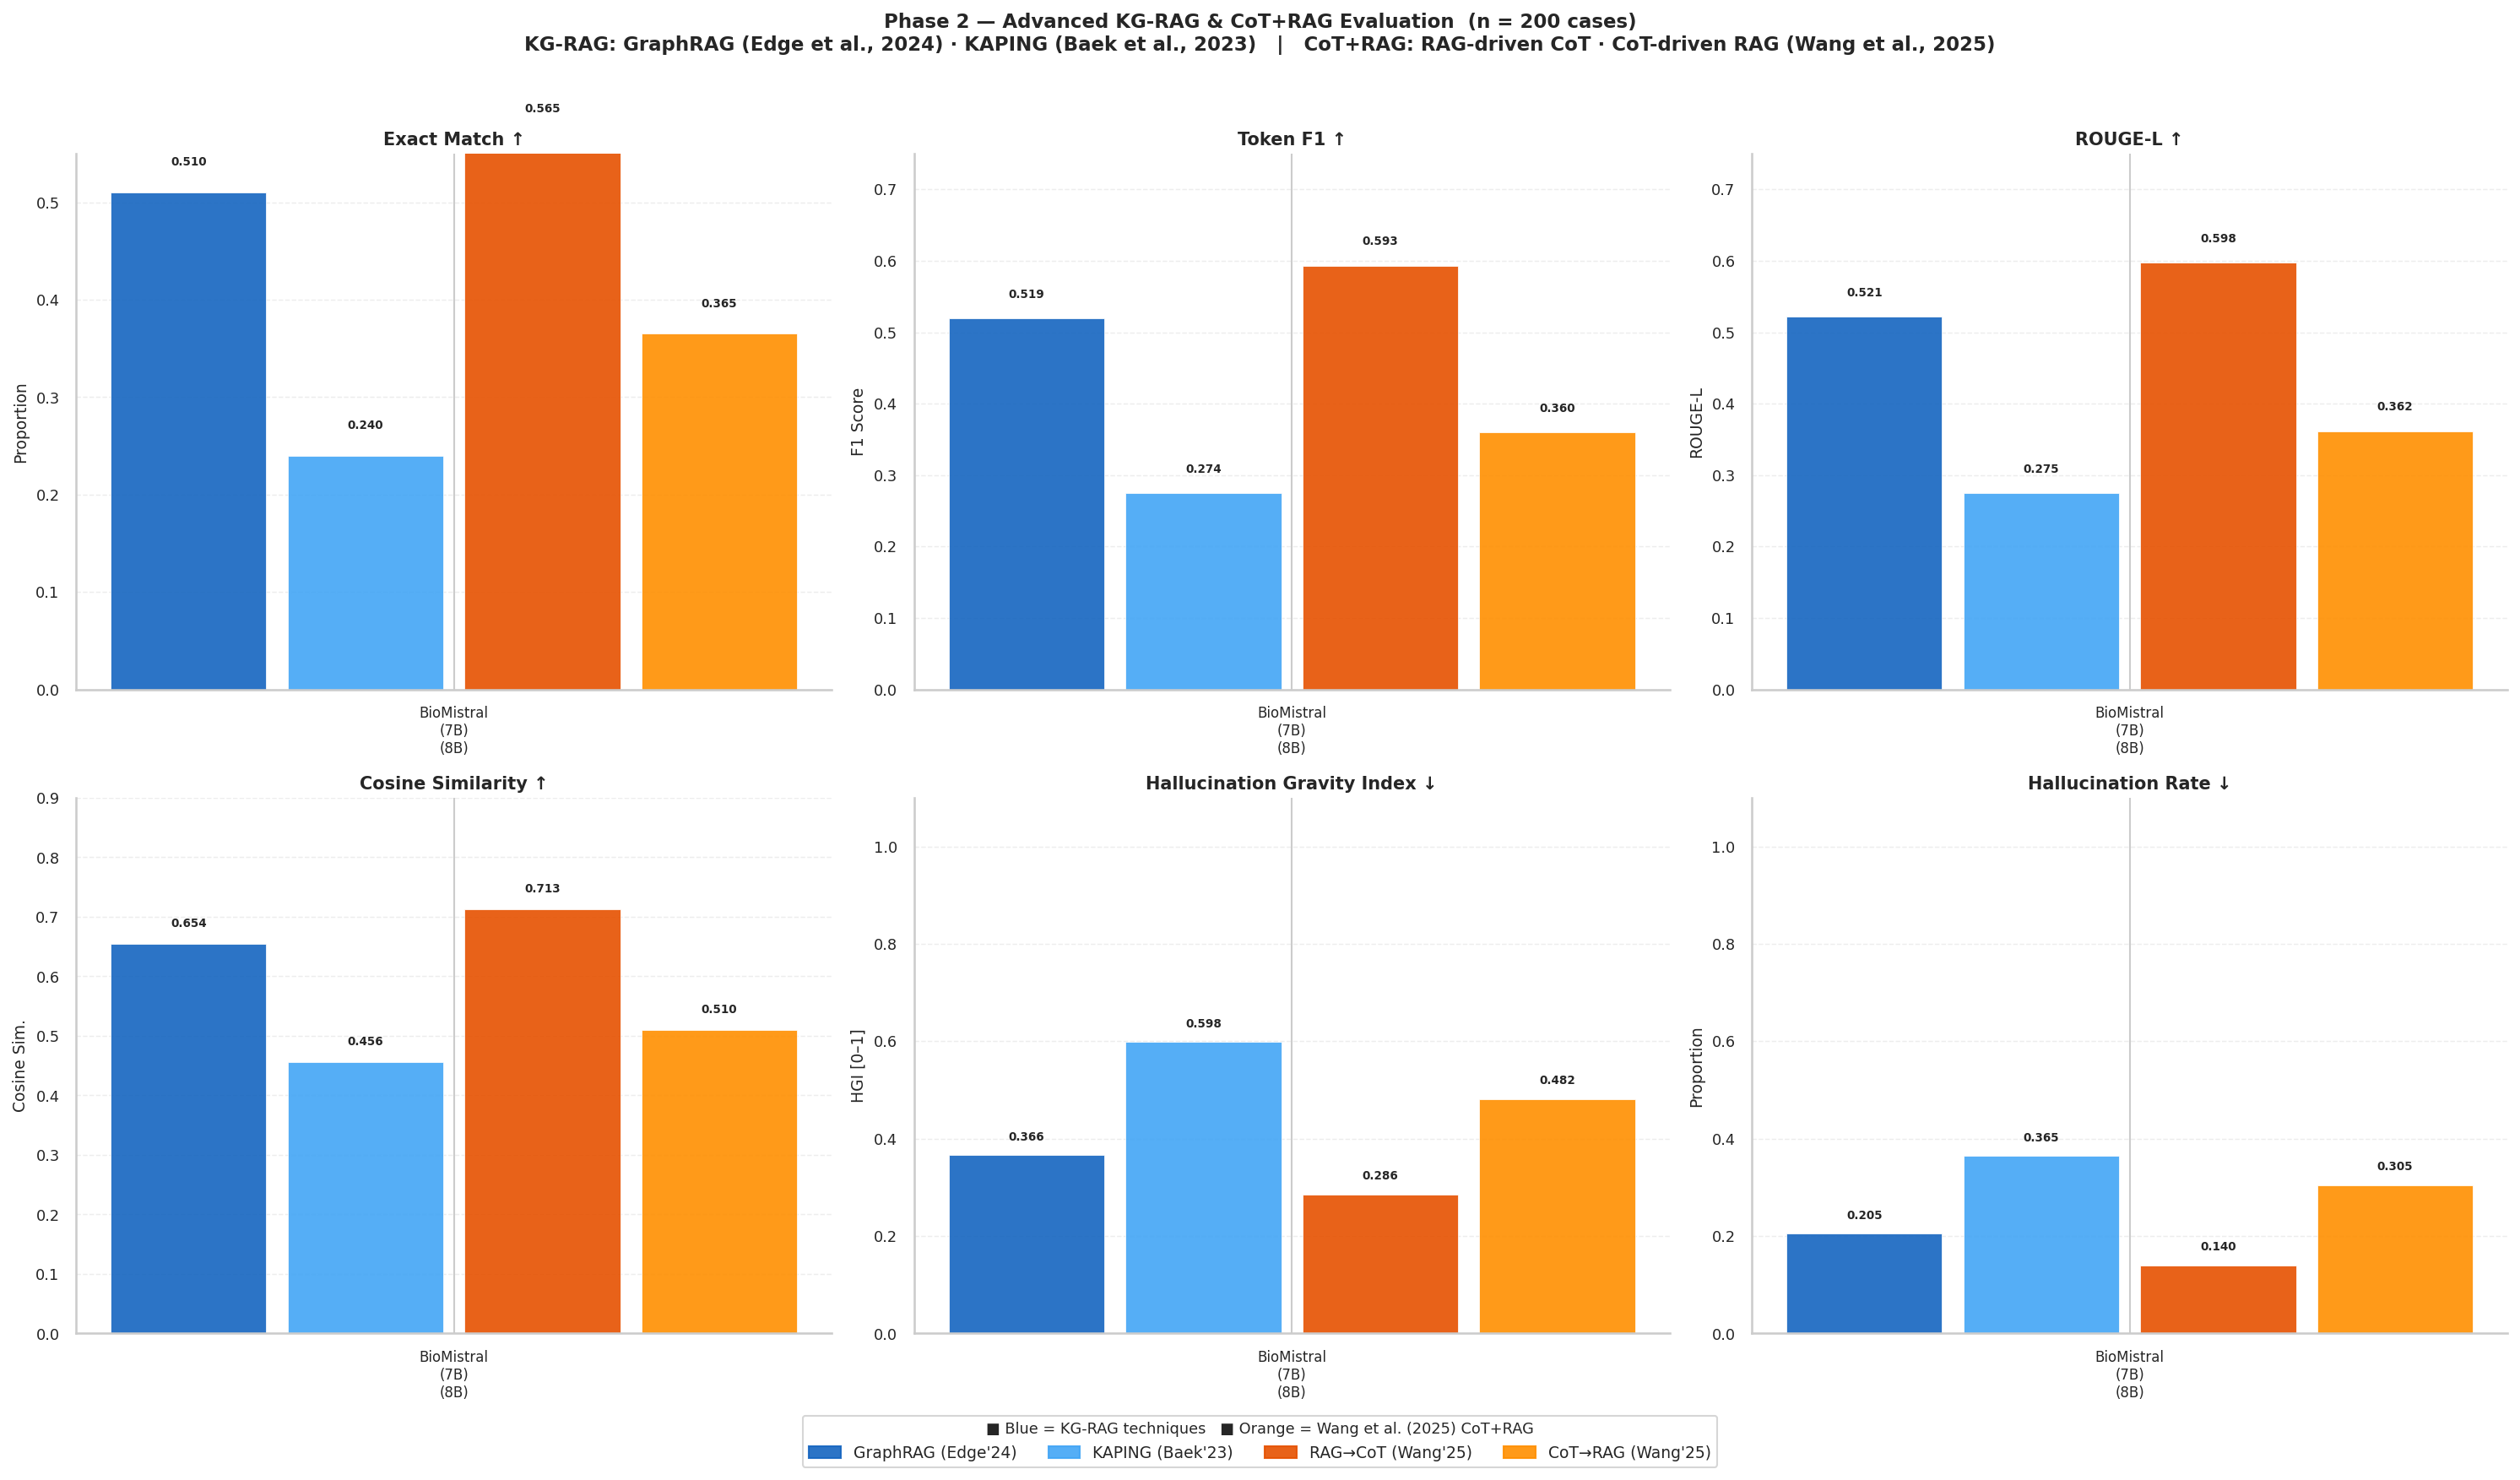

Saved: results-mistral-phenopacket/phase2_advanced_evaluation.png


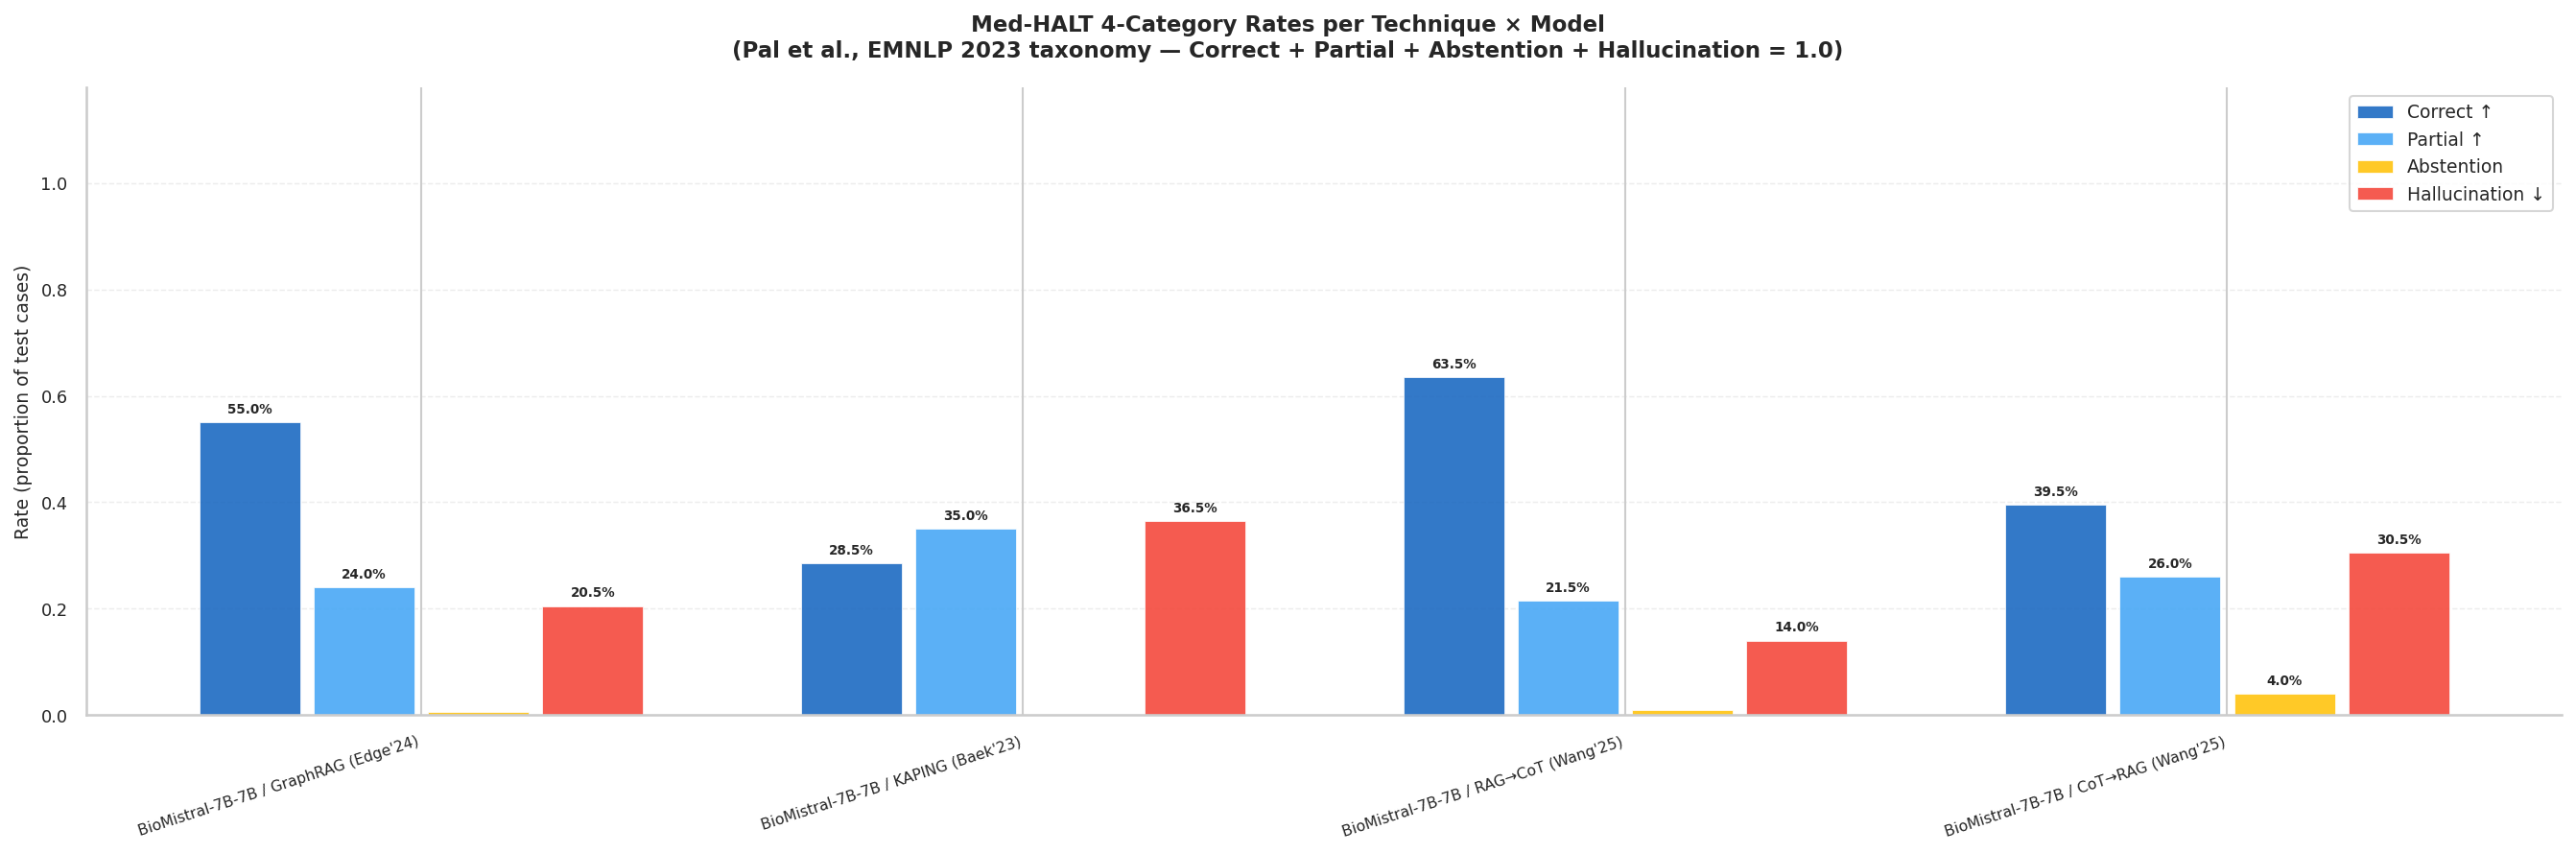

Saved: results-mistral-phenopacket/phase2_med_halt_breakdown.png


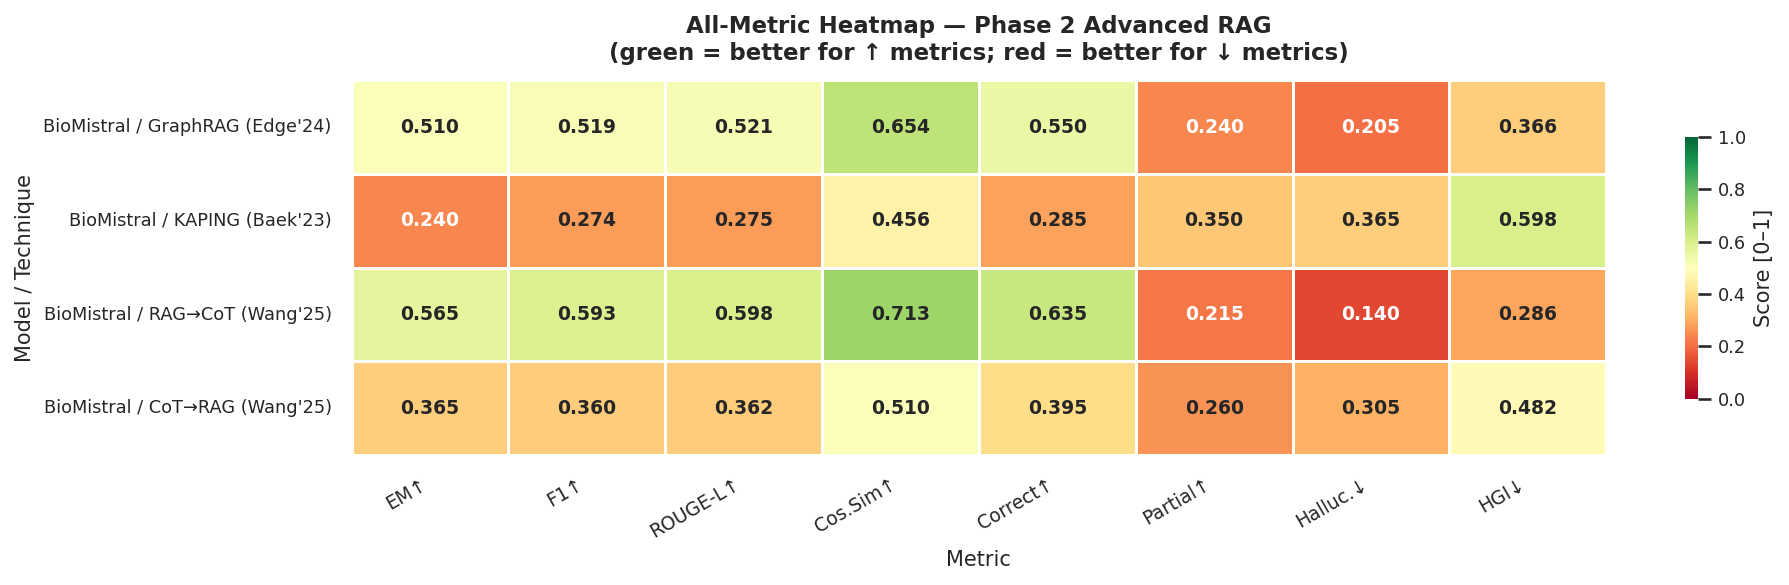

Saved: results-mistral-phenopacket/phase2_heatmap.png

  SUMMARY TABLE — Phase 2 Advanced RAG (all 4 techniques × all models)
     Model        Technique                                Paper   EM↑   F1↑ ROUGE-L↑ Cos.Sim↑ Correct↑ Partial↑ Halluc.↓ Abst.  HGI↓
BioMistral         GraphRAG Edge et al., 2024 (arXiv:2404.16130) 0.510 0.519    0.521    0.654    0.550    0.240    0.205 0.005 0.366
BioMistral KG-Augmented RAG Baek et al., 2023 (arXiv:2306.04136) 0.240 0.274    0.275    0.456    0.285    0.350    0.365 0.000 0.598
BioMistral   RAG-driven CoT Wang et al., 2025 (arXiv:2503.12286) 0.565 0.593    0.598    0.713    0.635    0.215    0.140 0.010 0.286
BioMistral   CoT-driven RAG Wang et al., 2025 (arXiv:2503.12286) 0.365 0.360    0.362    0.510    0.395    0.260    0.305 0.040 0.482


,Model,Technique,Paper,EM↑,F1↑,ROUGE-L↑,Cos.Sim↑,Correct↑,Partial↑,Halluc.↓,Abst.,HGI↓
0,BioMistral,GraphRAG,"Edge et al., 2024 (arXiv:2404.16130)",0.510,0.519,0.521,0.654,0.550,0.240,0.205,0.005,0.366
1,BioMistral,KG-Augmented RAG,"Baek et al., 2023 (arXiv:2306.04136)",0.240,0.274,0.275,0.456,0.285,0.350,0.365,0.000,0.598
2,BioMistral,RAG-driven CoT,"Wang et al., 2025 (arXiv:2503.12286)",0.565,0.593,0.598,0.713,0.635,0.215,0.140,0.010,0.286
3,BioMistral,CoT-driven RAG,"Wang et al., 2025 (arXiv:2503.12286)",0.365,0.360,0.362,0.510,0.395,0.260,0.305,0.040,0.482


In [13]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
df_viz = final_results_df.copy()

# ── Short labels & colour palette ──────────────────────────────────────────────
TECH_SHORT = {
    "GraphRAG":         "GraphRAG\n(Edge'24)",
    "KG-Augmented RAG": "KAPING\n(Baek'23)",
    "RAG-driven CoT":   "RAG→CoT\n(Wang'25)",
    "CoT-driven RAG":   "CoT→RAG\n(Wang'25)",
}
TECH_COLOR = {
    "GraphRAG":         "#1565C0",
    "KG-Augmented RAG": "#42A5F5",
    "RAG-driven CoT":   "#E65100",
    "CoT-driven RAG":   "#FF8F00",
}
df_viz["Technique_Short"] = df_viz["Technique"].map(TECH_SHORT).fillna(df_viz["Technique"])
df_viz["Color"]           = df_viz["Technique"].map(TECH_COLOR).fillna("#888888")

# ── Paper-quality rcParams ──────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":       "sans-serif",
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   8.5,
    "ytick.labelsize":   8.5,
    "legend.fontsize":   8.5,
    "axes.spines.top":   False,
    "axes.spines.right": False,
})

# ══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Multi-Metric Grouped Bar Chart
# ══════════════════════════════════════════════════════════════════════════════
def _bar_group(ax, col, title, ylabel, fmt="{:.3f}", ylim=(0, 1.10), dy=0.025):
    models  = df_viz["Model"].unique()
    techs   = list(TECH_SHORT.keys())
    n_t     = len(techs)
    n_m     = len(models)
    width   = 0.65 / n_t
    x       = np.arange(n_m)
    for j, tech in enumerate(techs):
        vals = [
            df_viz.loc[(df_viz["Model"] == m) & (df_viz["Technique"] == tech), col].values
            for m in models
        ]
        vals   = [float(v[0]) if len(v) > 0 else 0.0 for v in vals]
        offset = (j - n_t / 2 + 0.5) * width
        bars   = ax.bar(x + offset, vals, width * 0.88,
                        color=TECH_COLOR[tech],
                        label=TECH_SHORT[tech].replace("\n", " "),
                        alpha=0.90, edgecolor="white", linewidth=0.4)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, v + dy,
                    fmt.format(v), ha="center", va="bottom",
                    fontsize=6.5, fontweight="bold")
    ax.set_title(title, fontsize=10, fontweight="bold", pad=5)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(x)
    model_labels = [
        m.replace("BioMistral", "BioMistral\n(8B)").replace("BioMistral", "BioMistral\n(7B)")
        for m in models
    ]
    ax.set_xticklabels(model_labels, fontsize=8)
    ax.set_ylim(*ylim)
    ax.yaxis.grid(True, linestyle="--", alpha=0.35, linewidth=0.7)
    ax.set_axisbelow(True)

fig1, axes = plt.subplots(2, 3, figsize=(20, 11))
fig1.suptitle(
    f"Phase 2 — Advanced KG-RAG & CoT+RAG Evaluation  (n = {SAMPLE_SIZE} cases)\n"
    "KG-RAG: GraphRAG (Edge et al., 2024) · KAPING (Baek et al., 2023)   |   "
    "CoT+RAG: RAG-driven CoT · CoT-driven RAG (Wang et al., 2025)",
    fontsize=11, fontweight="bold", y=1.01,
)

_bar_group(axes[0, 0], "Exact_Match",        "Exact Match ↑",               "Proportion",  fmt="{:.3f}", ylim=(0, 0.55))
_bar_group(axes[0, 1], "Token_F1",           "Token F1 ↑",                  "F1 Score",    fmt="{:.3f}", ylim=(0, 0.75))
_bar_group(axes[0, 2], "ROUGE_L",            "ROUGE-L ↑",                   "ROUGE-L",     fmt="{:.3f}", ylim=(0, 0.75))
_bar_group(axes[1, 0], "Cosine_Sim",         "Cosine Similarity ↑",         "Cosine Sim.", fmt="{:.3f}", ylim=(0, 0.90))
_bar_group(axes[1, 1], "HGI",                "Hallucination Gravity Index ↓", "HGI [0–1]", fmt="{:.3f}", ylim=(0, 1.10))
_bar_group(axes[1, 2], "Hallucination_Rate", "Hallucination Rate ↓",        "Proportion",  fmt="{:.3f}", ylim=(0, 1.10))

handles = [mpatches.Patch(color=c, label=TECH_SHORT[t].replace("\n", " "), alpha=0.90)
           for t, c in TECH_COLOR.items()]
fig1.legend(handles=handles, loc="lower center", ncol=4, fontsize=9,
            bbox_to_anchor=(0.5, -0.04), frameon=True,
            title="■ Blue = KG-RAG techniques   ■ Orange = Wang et al. (2025) CoT+RAG",
            title_fontsize=8.5)

plt.tight_layout()
fig_path1 = os.path.join(OUTPUT_DIR, "phase2_advanced_evaluation.png")
plt.savefig(fig_path1, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path1}")

# ══════════════════════════════════════════════════════════════════════════════
# Figure 2 — Med-HALT 4-Category Grouped Bar Chart
# ══════════════════════════════════════════════════════════════════════════════
cats    = ["Semantic_Accuracy", "Partial_Accuracy", "Abstention_Rate", "Hallucination_Rate"]
clabels = ["Correct ↑", "Partial ↑", "Abstention", "Hallucination ↓"]
ccolors = ["#1565C0", "#42A5F5", "#FFC107", "#F44336"]

df_viz["x_label"] = (
    df_viz["Model"].str.replace("BioMistral", "BioMistral-7B").str.replace("BioMistral", "BioMistral-7B")
    + " / " + df_viz["Technique_Short"].str.replace("\n", " ")
)

fig2, ax2 = plt.subplots(figsize=(18, 6))
fig2.suptitle(
    "Med-HALT 4-Category Rates per Technique × Model\n"
    "(Pal et al., EMNLP 2023 taxonomy — Correct + Partial + Abstention + Hallucination = 1.0)",
    fontsize=11, fontweight="bold",
)
width2 = 0.19
x2     = np.arange(len(df_viz))
for j, (cat, clabel, cc) in enumerate(zip(cats, clabels, ccolors)):
    bars2 = ax2.bar(x2 + j * width2, df_viz[cat], width2 * 0.88,
                    label=clabel, color=cc, alpha=0.87, edgecolor="white", linewidth=0.4)
    for bar in bars2:
        h = bar.get_height()
        if h >= 0.025:
            ax2.text(bar.get_x() + bar.get_width() / 2, h + 0.012,
                     f"{h:.1%}", ha="center", va="bottom", fontsize=6.5, fontweight="bold")
ax2.set_xticks(x2 + 1.5 * width2)
ax2.set_xticklabels(df_viz["x_label"], fontsize=7.5, rotation=18, ha="right")
ax2.set_ylim(0, 1.18)
ax2.set_ylabel("Rate (proportion of test cases)", fontsize=9)
ax2.yaxis.grid(True, linestyle="--", alpha=0.35, linewidth=0.7)
ax2.set_axisbelow(True)
ax2.legend(loc="upper right", fontsize=9, frameon=True)
plt.tight_layout()
fig_path2 = os.path.join(OUTPUT_DIR, "phase2_med_halt_breakdown.png")
plt.savefig(fig_path2, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path2}")

# ══════════════════════════════════════════════════════════════════════════════
# Figure 3 — All-Metric Heatmap (publication-ready)
# ══════════════════════════════════════════════════════════════════════════════
metric_cols   = ["Exact_Match", "Token_F1", "ROUGE_L", "Cosine_Sim",
                 "Semantic_Accuracy", "Partial_Accuracy", "Hallucination_Rate", "HGI"]
metric_labels = ["EM↑", "F1↑", "ROUGE-L↑", "Cos.Sim↑",
                 "Correct↑", "Partial↑", "Halluc.↓", "HGI↓"]

df_viz["row_label"] = (
    df_viz["Model"].str.split("-").str[0]
    + " / " + df_viz["Technique_Short"].str.replace("\n", " ")
)
heatmap_data         = df_viz.set_index("row_label")[metric_cols].astype(float)
heatmap_data.columns = metric_labels

fig3, ax3 = plt.subplots(figsize=(13, max(4, len(heatmap_data) * 0.55 + 1.5)))
sns.heatmap(
    heatmap_data, annot=True, fmt=".3f", cmap="RdYlGn",
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 9, "weight": "bold"},
    vmin=0, vmax=1, ax=ax3, cbar_kws={"shrink": 0.7, "label": "Score [0–1]"},
)
ax3.set_title(
    "All-Metric Heatmap — Phase 2 Advanced RAG\n"
    "(green = better for ↑ metrics; red = better for ↓ metrics)",
    fontsize=11, fontweight="bold", pad=10,
)
ax3.set_xlabel("Metric", fontsize=10)
ax3.set_ylabel("Model / Technique", fontsize=10)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=30, ha="right", fontsize=9)
ax3.set_yticklabels(ax3.get_yticklabels(), rotation=0, fontsize=8.5)
plt.tight_layout()
fig_path3 = os.path.join(OUTPUT_DIR, "phase2_heatmap.png")
plt.savefig(fig_path3, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path3}")

# ══════════════════════════════════════════════════════════════════════════════
# Console Summary Table
# ══════════════════════════════════════════════════════════════════════════════
summary_cols = ["Model", "Technique", "Paper",
                "Exact_Match", "Token_F1", "ROUGE_L", "Cosine_Sim",
                "Semantic_Accuracy", "Partial_Accuracy",
                "Hallucination_Rate", "Abstention_Rate", "HGI"]
df_sum = df_viz[summary_cols].copy()
df_sum.columns = ["Model", "Technique", "Paper",
                  "EM↑", "F1↑", "ROUGE-L↑", "Cos.Sim↑",
                  "Correct↑", "Partial↑", "Halluc.↓", "Abst.", "HGI↓"]
for col in df_sum.columns[3:]:
    df_sum[col] = df_sum[col].apply(lambda x: f"{float(x):.3f}")

print("\n" + "=" * 120)
print("  SUMMARY TABLE — Phase 2 Advanced RAG (all 4 techniques × all models)")
print("=" * 120)
print(df_sum.to_string(index=False))
display(df_sum)


---
## 11. Hallucination Gravity Index (HGI) — Severity Analysis

The HGI is a **custom continuous severity metric** in [0, 1] that complements the categorical Med-HALT classification:

| Category | HGI Range | Interpretation |
|----------|-----------|----------------|
| Correct | 0.00 | No hallucination |
| Abstention | 0.10 | Model refused to diagnose |
| Partially correct | 0.35–0.70 | Some relevant information, incomplete |
| Hallucination | 0.70–1.00 | Fabricated or wrong diagnosis |

HGI SUMMARY (values in %)


,model,technique_display,HGI_mean,HGI_median,HGI_std,Cases
3,BioMistral,RAG-driven CoT,28.578434,0.0,39.223147,200
1,BioMistral,GraphRAG,36.587414,0.0,41.823667,200
0,BioMistral,CoT-driven RAG,48.166914,70.0,42.823855,200
2,BioMistral,KG-Augmented RAG,59.814863,70.0,39.533882,200



AGGREGATED RESULTS WITH HGI


,Model,Embedding,Embedding_Model,Technique,Paper,Exact_Match,Token_F1,ROUGE_L,Cosine_Sim,Semantic_Accuracy,Partial_Accuracy,Hallucination_Rate,Abstention_Rate,HGI,Avg_Inference_Time(s),technique_display,HGI_mean,HGI_median,HGI_std,Cases
0,BioMistral,fast,sentence-transformers/all-MiniLM-L6-v2,GraphRAG,"Edge et al., 2024 (arXiv:2404.16130)",0.510,0.519382,0.521346,0.654092,0.550,0.240,0.205,0.005,0.365874,29.600877,GraphRAG,36.587414,0.0,41.823667,200
1,BioMistral,fast,sentence-transformers/all-MiniLM-L6-v2,KG-Augmented RAG,"Baek et al., 2023 (arXiv:2306.04136)",0.240,0.274281,0.274554,0.455761,0.285,0.350,0.365,0.000,0.598149,24.831737,KG-Augmented RAG,59.814863,70.0,39.533882,200
2,BioMistral,fast,sentence-transformers/all-MiniLM-L6-v2,RAG-driven CoT,"Wang et al., 2025 (arXiv:2503.12286)",0.565,0.593348,0.597787,0.712558,0.635,0.215,0.140,0.010,0.285784,18.889343,RAG-driven CoT,28.578434,0.0,39.223147,200
3,BioMistral,fast,sentence-transformers/all-MiniLM-L6-v2,CoT-driven RAG,"Wang et al., 2025 (arXiv:2503.12286)",0.365,0.360103,0.361714,0.509582,0.395,0.260,0.305,0.040,0.481669,29.748627,CoT-driven RAG,48.166914,70.0,42.823855,200



Saved CSV files:
  results-mistral-phenopacket/phase2_details_with_gravity.csv
  results-mistral-phenopacket/phase2_hgi_summary.csv
  results-mistral-phenopacket/phase2_results_with_hgi.csv


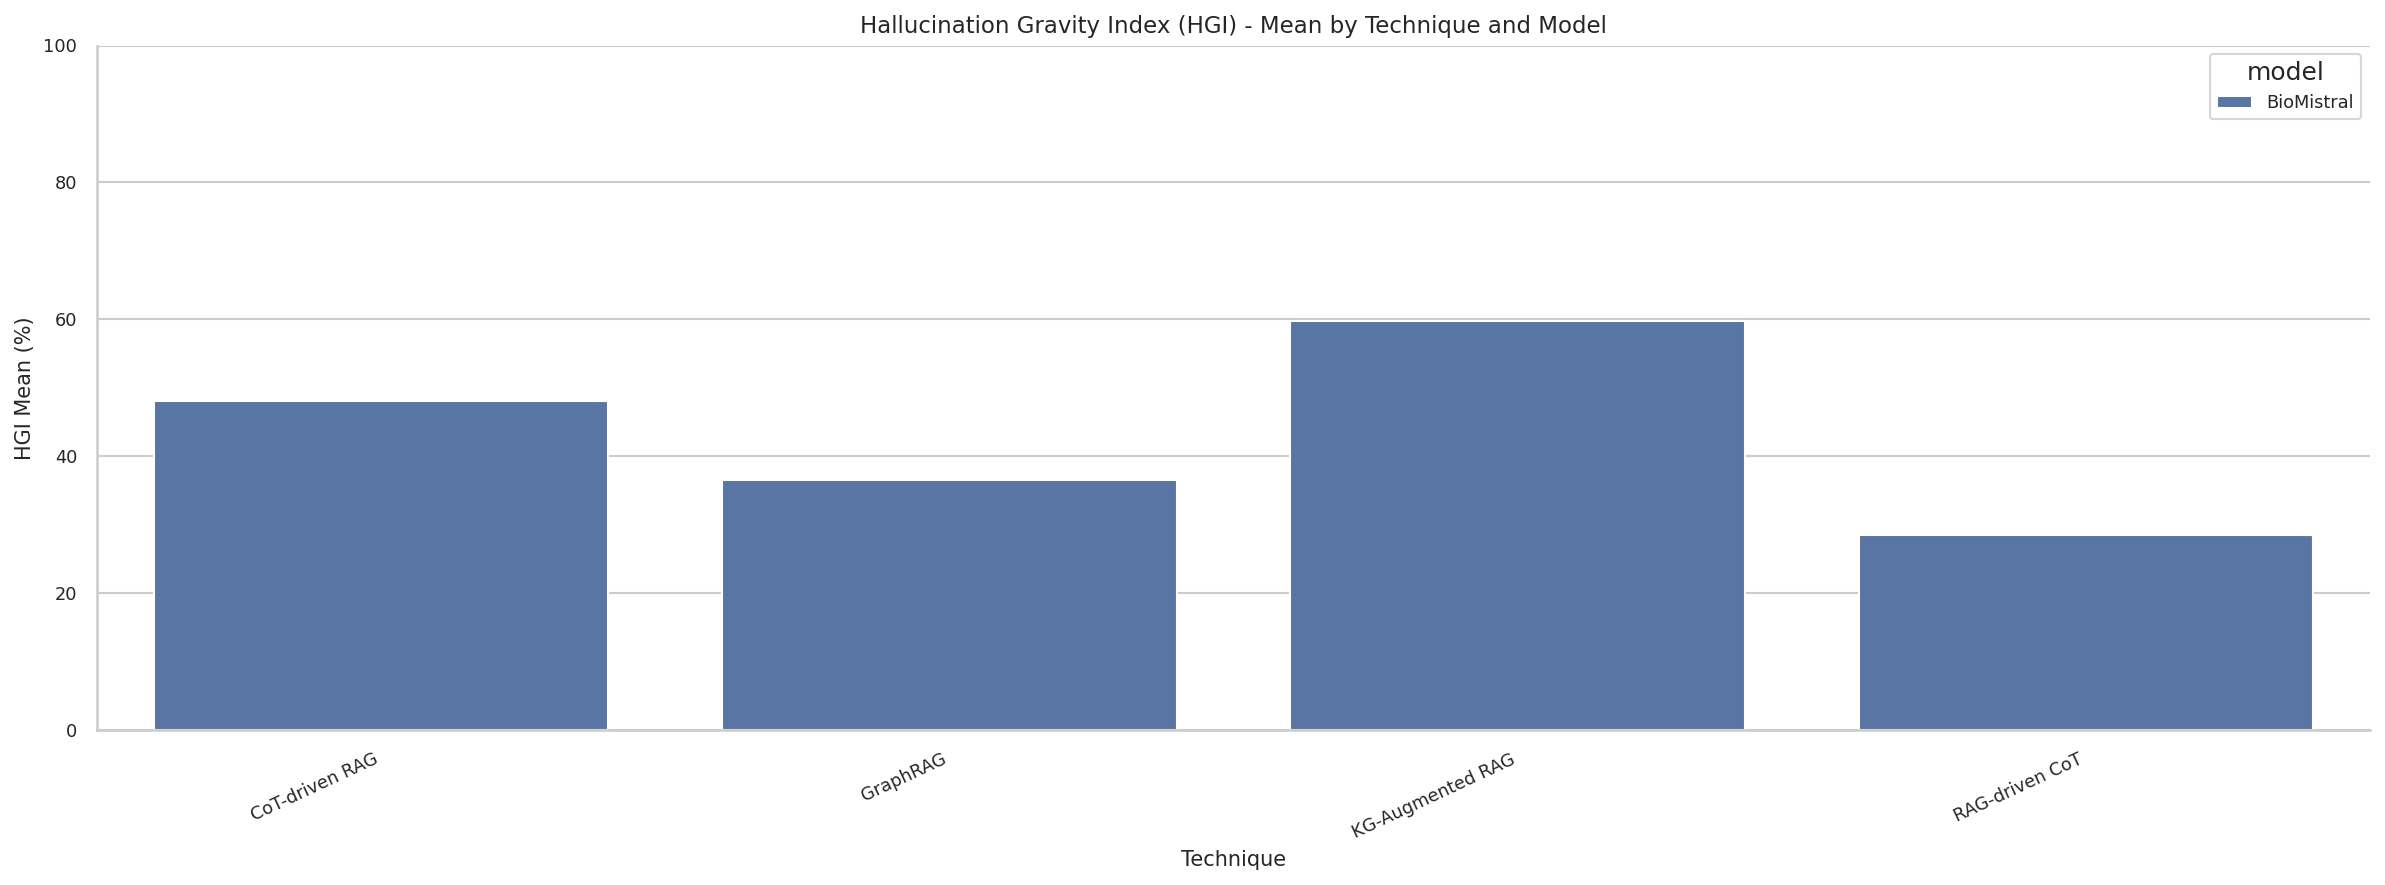

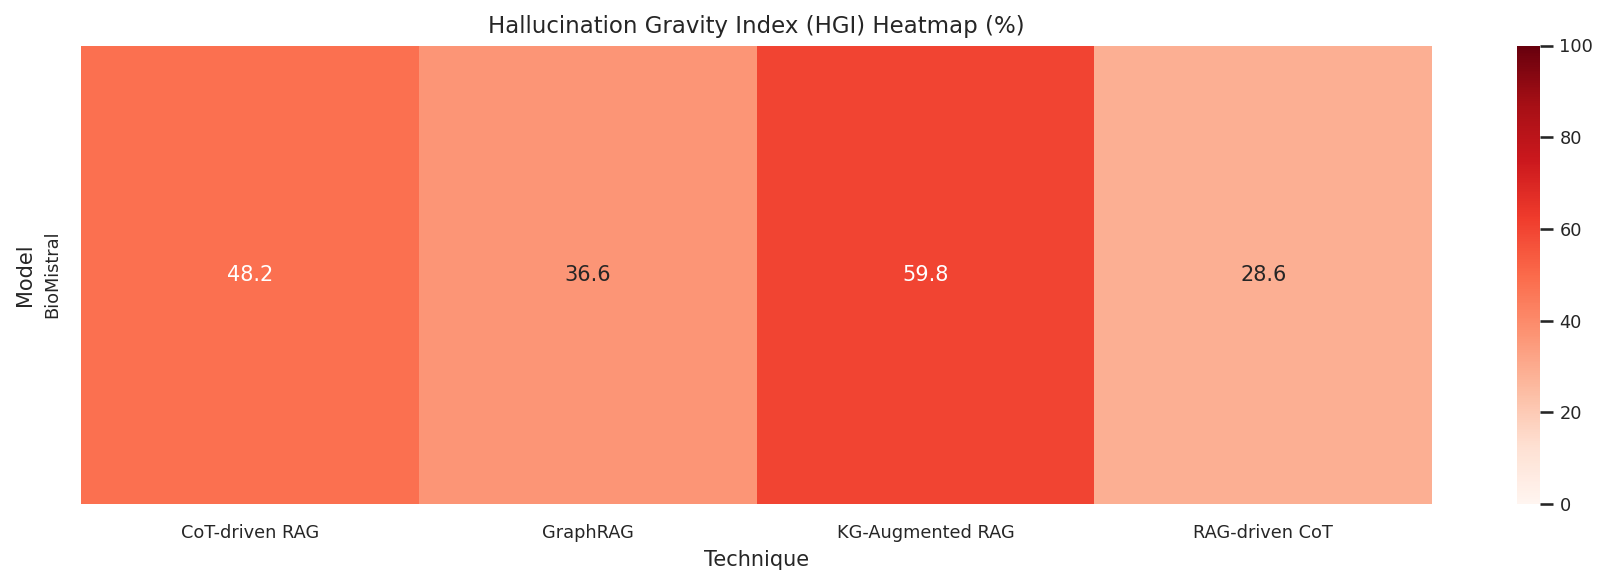

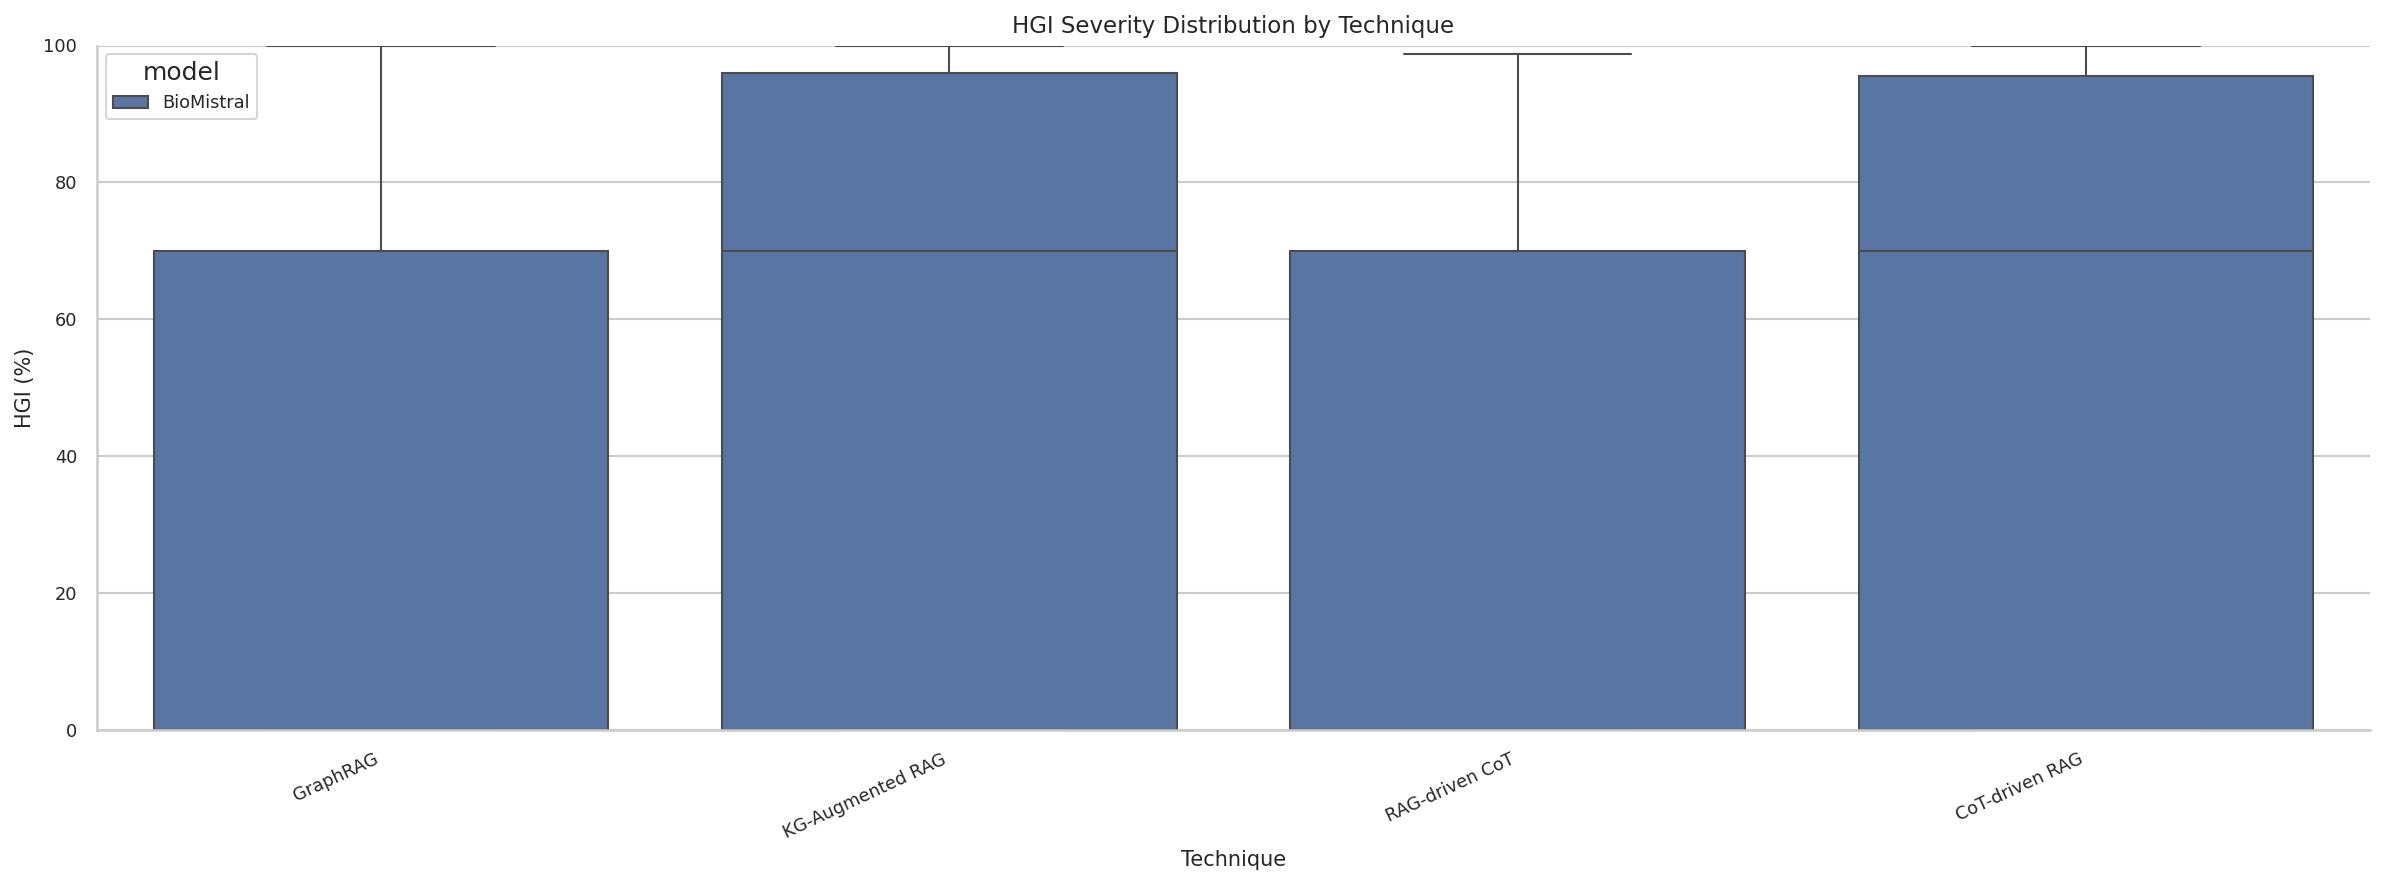

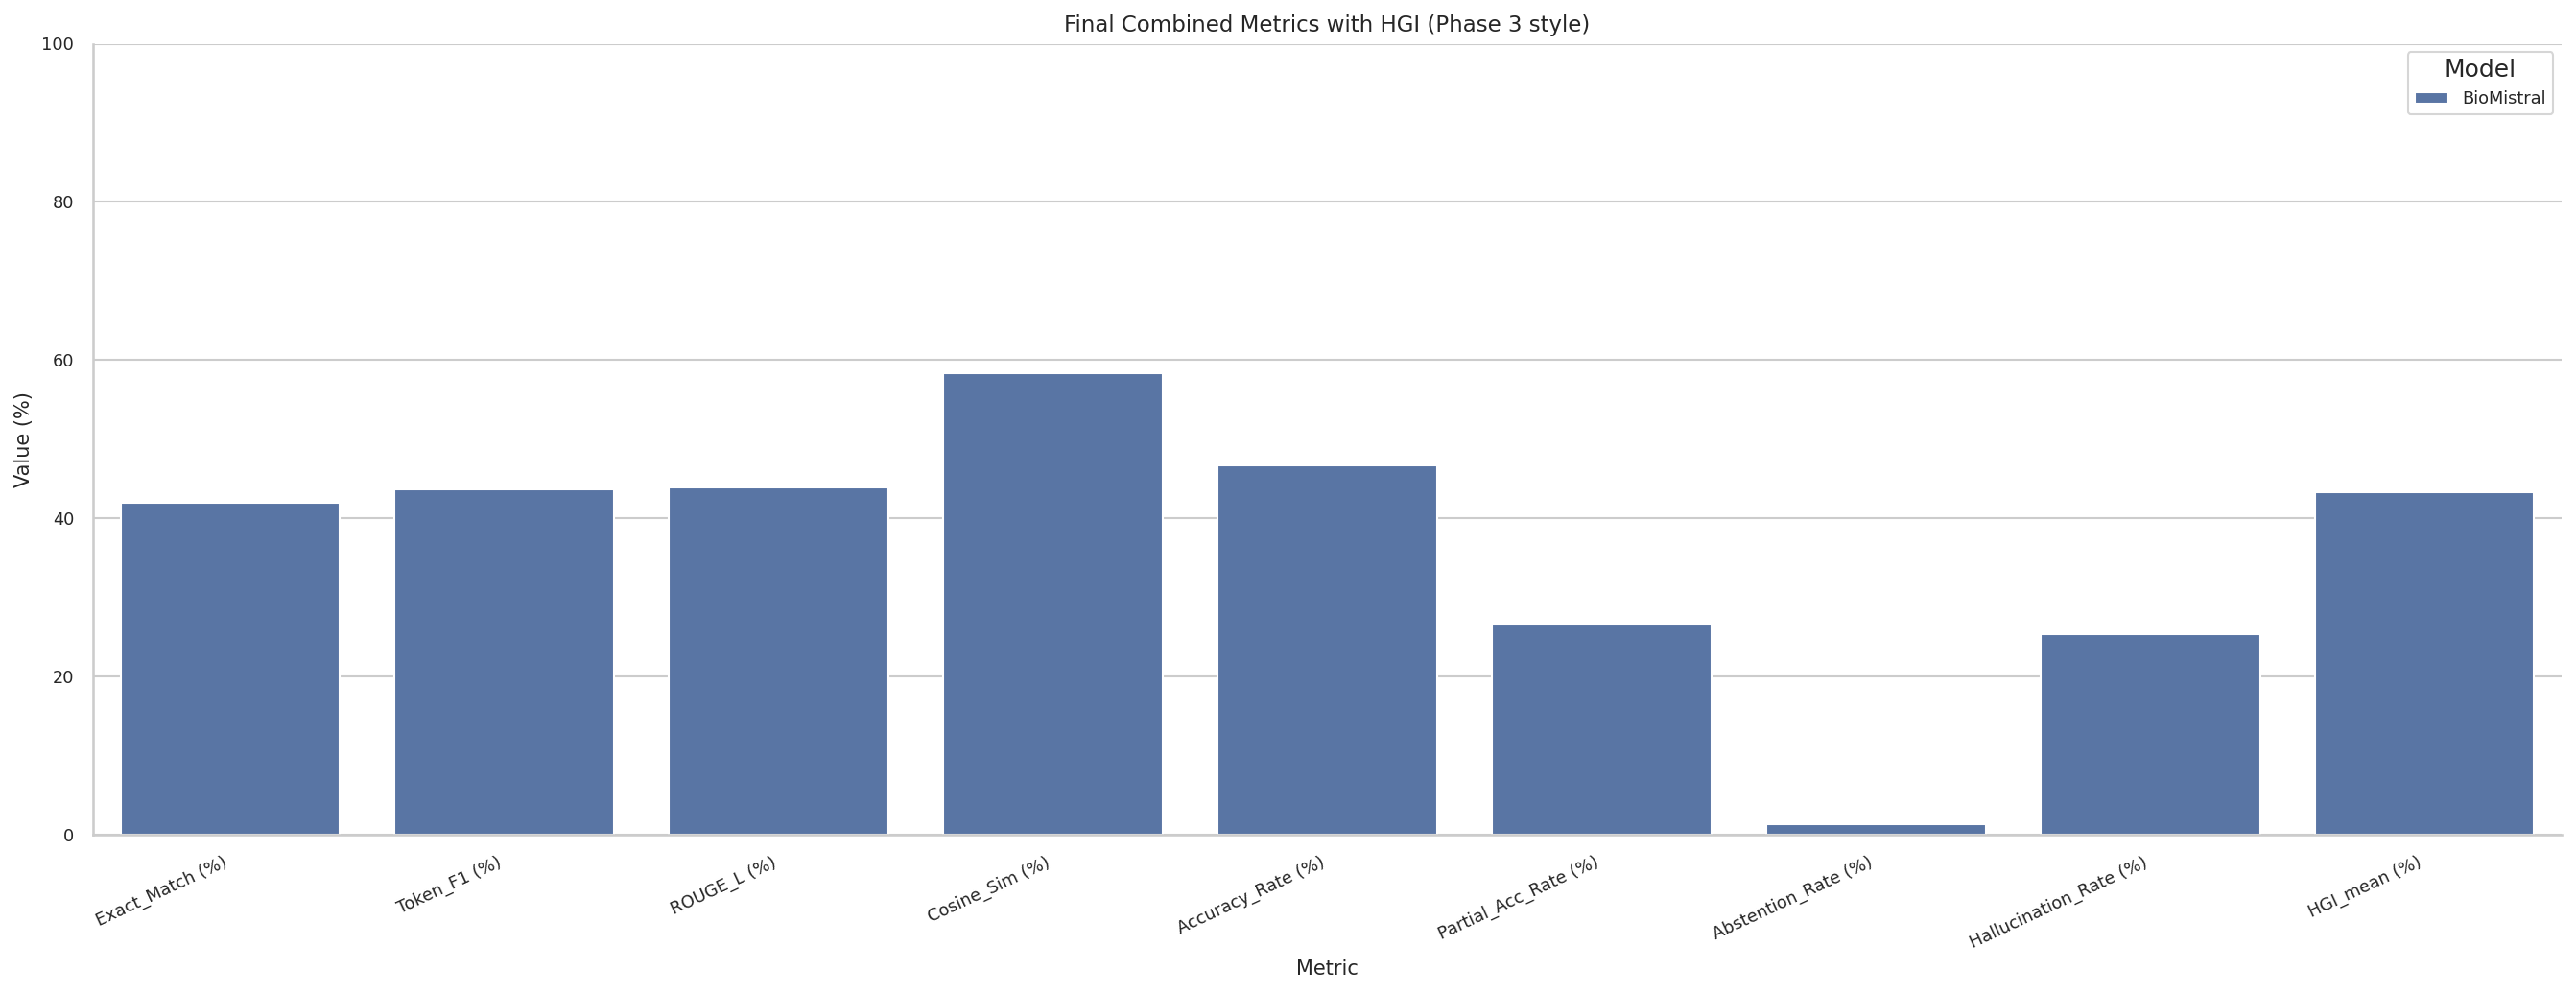


Saved plots:
  results-mistral-phenopacket/phase2_plot_hgi_bar.png
  results-mistral-phenopacket/phase2_plot_hgi_heatmap.png
  results-mistral-phenopacket/phase2_plot_hgi_distribution.png
  results-mistral-phenopacket/phase2_plot_final_combined_metrics_with_hgi.png


In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if "all_results_df" not in globals() or "all_details" not in globals():
    raise ValueError("Run evaluation first (Cell 19) so all_results_df and all_details are available.")

df_details_hg = pd.DataFrame(all_details).copy()
if df_details_hg.empty:
    raise ValueError("No detail rows found in all_details. Re-run evaluation cell.")


def _clip01(x):
    try:
        return float(np.clip(float(x), 0.0, 1.0))
    except Exception:
        return 0.0


def hallucination_gravity(row):
    """Custom HGI severity metric in [0,1], then scaled to percent for plots."""
    category = str(row.get("category", "")).strip().lower()
    em = _clip01(row.get("exact_match", 0.0))
    f1 = _clip01(row.get("token_f1", 0.0))
    cos = _clip01(row.get("cosine_sim", row.get("cosine_similarity", 0.0)))

    if category == "correct":
        return 0.00
    if category == "abstention":
        return 0.10
    if category == "partially_correct":
        score = 0.35 + 0.35 * (1.0 - cos) + 0.30 * (1.0 - f1)
        return float(np.clip(score, 0.35, 0.70))

    score = 0.70 + 0.20 * (1.0 - cos) + 0.10 * (1.0 - em)
    return float(np.clip(score, 0.70, 1.00))


if "embedding_profile" in df_details_hg.columns and df_details_hg["embedding_profile"].nunique() > 1:
    df_details_hg["technique_display"] = (
        df_details_hg["technique"].astype(str)
        + " [" + df_details_hg["embedding_profile"].astype(str) + "]"
    )
else:
    df_details_hg["technique_display"] = df_details_hg["technique"].astype(str)

df_details_hg["hallucination_gravity"] = df_details_hg.apply(hallucination_gravity, axis=1) * 100.0

summary_gravity = (
    df_details_hg
    .groupby(["model", "technique_display"], as_index=False)
    .agg(
        HGI_mean=("hallucination_gravity", "mean"),
        HGI_median=("hallucination_gravity", "median"),
        HGI_std=("hallucination_gravity", "std"),
        Cases=("hallucination_gravity", "count"),
    )
)
summary_gravity["HGI_std"] = summary_gravity["HGI_std"].fillna(0.0)

df_results_hg = all_results_df.copy()
if "Embedding" in df_results_hg.columns and df_results_hg["Embedding"].nunique() > 1:
    df_results_hg["technique_display"] = (
        df_results_hg["Technique"].astype(str)
        + " [" + df_results_hg["Embedding"].astype(str) + "]"
    )
else:
    df_results_hg["technique_display"] = df_results_hg["Technique"].astype(str)

df_results_hg = df_results_hg.merge(
    summary_gravity[["model", "technique_display", "HGI_mean", "HGI_median", "HGI_std", "Cases"]],
    left_on=["Model", "technique_display"],
    right_on=["model", "technique_display"],
    how="left",
).drop(columns=["model"])

print("=" * 100)
print("HGI SUMMARY (values in %)" )
print("=" * 100)
display(summary_gravity.sort_values(["model", "HGI_mean", "technique_display"]))

print("\n" + "=" * 100)
print("AGGREGATED RESULTS WITH HGI")
print("=" * 100)
display(df_results_hg)

out_dir = OUTPUT_DIR if "OUTPUT_DIR" in globals() else "."
os.makedirs(out_dir, exist_ok=True)

csv_details_hg = os.path.join(out_dir, "phase2_details_with_gravity.csv")
csv_summary_hg = os.path.join(out_dir, "phase2_hgi_summary.csv")
csv_results_hg = os.path.join(out_dir, "phase2_results_with_hgi.csv")

df_details_hg.to_csv(csv_details_hg, index=False)
summary_gravity.to_csv(csv_summary_hg, index=False)
df_results_hg.to_csv(csv_results_hg, index=False)

print("\nSaved CSV files:")
print("  " + csv_details_hg)
print("  " + csv_summary_hg)
print("  " + csv_results_hg)

# Plot 1 - HGI mean bar chart
plt.figure(figsize=(16, 6))
sns.barplot(data=summary_gravity, x="technique_display", y="HGI_mean", hue="model")
plt.title("Hallucination Gravity Index (HGI) - Mean by Technique and Model")
plt.xlabel("Technique")
plt.ylabel("HGI Mean (%)")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plot1 = os.path.join(out_dir, "phase2_plot_hgi_bar.png")
plt.savefig(plot1, dpi=150, bbox_inches="tight")
plt.show()

# Plot 2 - HGI heatmap
pivot_hgi = summary_gravity.pivot(index="model", columns="technique_display", values="HGI_mean")
plt.figure(figsize=(max(12, 1.6 * len(pivot_hgi.columns)), 4))
sns.heatmap(pivot_hgi, annot=True, fmt=".1f", cmap="Reds", vmin=0, vmax=100)
plt.title("Hallucination Gravity Index (HGI) Heatmap (%)")
plt.xlabel("Technique")
plt.ylabel("Model")
plt.tight_layout()
plot2 = os.path.join(out_dir, "phase2_plot_hgi_heatmap.png")
plt.savefig(plot2, dpi=150, bbox_inches="tight")
plt.show()

# Plot 3 - HGI distribution by technique
plt.figure(figsize=(16, 6))
sns.boxplot(data=df_details_hg, x="technique_display", y="hallucination_gravity", hue="model")
plt.title("HGI Severity Distribution by Technique")
plt.xlabel("Technique")
plt.ylabel("HGI (%)")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 100)
plt.tight_layout()
plot3 = os.path.join(out_dir, "phase2_plot_hgi_distribution.png")
plt.savefig(plot3, dpi=150, bbox_inches="tight")
plt.show()

# Plot 4 - Combined metrics (percent scale)
df_plot = df_results_hg.copy()
metric_map = [
    ("Exact_Match", "Exact_Match (%)"),
    ("Token_F1", "Token_F1 (%)"),
    ("ROUGE_L", "ROUGE_L (%)"),
    ("Cosine_Sim", "Cosine_Sim (%)"),
    ("Semantic_Accuracy", "Accuracy_Rate (%)"),
    ("Partial_Accuracy", "Partial_Acc_Rate (%)"),
    ("Abstention_Rate", "Abstention_Rate (%)"),
    ("Hallucination_Rate", "Hallucination_Rate (%)"),
]
for src, dst in metric_map:
    if src in df_plot.columns:
        df_plot[dst] = pd.to_numeric(df_plot[src], errors="coerce") * 100.0

if "HGI_mean" in df_plot.columns:
    df_plot["HGI_mean (%)"] = pd.to_numeric(df_plot["HGI_mean"], errors="coerce")

plot_metrics = [
    "Exact_Match (%)",
    "Token_F1 (%)",
    "ROUGE_L (%)",
    "Cosine_Sim (%)",
    "Accuracy_Rate (%)",
    "Partial_Acc_Rate (%)",
    "Abstention_Rate (%)",
    "Hallucination_Rate (%)",
    "HGI_mean (%)",
]
plot_metrics = [m for m in plot_metrics if m in df_plot.columns]

melted = df_plot.melt(
    id_vars=["Model", "technique_display"],
    value_vars=plot_metrics,
    var_name="Metric",
    value_name="Value",
)
plt.figure(figsize=(18, 7))
sns.barplot(data=melted, x="Metric", y="Value", hue="Model", errorbar=None)
plt.title("Final Combined Metrics with HGI (Phase 3 style)")
plt.xlabel("Metric")
plt.ylabel("Value (%)")
plt.ylim(0, 100)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plot4 = os.path.join(out_dir, "phase2_plot_final_combined_metrics_with_hgi.png")
plt.savefig(plot4, dpi=150, bbox_inches="tight")
plt.show()

print("\nSaved plots:")
print("  " + plot1)
print("  " + plot2)
print("  " + plot3)
print("  " + plot4)